# Phase 2: Build and Validate Market-Level Indicators

Computes daily returns and volatility, engineers six mood indicators, applies Principal Component Analysis (PCA) to isolate a 'Systemic Stress' factor, and validates these signals against historical market drawdowns.

## Steps
1. Load cleaned data from `data/processed/nasdaq_processed.csv` and analyze distributions of Adj Close and Volume
2. Compute daily log returns for each stock
3. Calculate daily market volatility index (cross-sectional standard deviation of returns per day)
4. Validate return distributions and volatility through summary statistics and visualizations
5. Experiment with smoothing windows (5, 10, 20, 30 days) and select 20-day window for optimal balance
6. Compute mood indicators: direction, volume, correlation, breadth, ATR, and volatility
7. Standardize all indicators using rolling Z-score (252-day window) to create mood index
8. Create `market_divergence` feature (difference between market direction and breadth)
9. Perform Principal Component Analysis (PCA) on standardized indicators to extract latent "Systemic Stress" (PC2) and "Market Trend" (PC1) signals
10. Calculate Market Drawdown to objectively define market regimes (Correction vs. Bear Market)
11. Validate the Systemic Stress Index (PC2) by visualizing its alignment with historical Drawdown periods and known crisis events
12. Save results to `data/processed/nasdaq_features.csv`, `data/processed/market_volatility.csv`, `data/processed/kmeans_features.csv`, `data/processed/extended_features.csv`, and the trained model to `data/processed/pca_mood_model.joblib`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from tqdm import tqdm
import joblib

# Add project root to path
sys.path.append(str(Path('..').resolve()))

from sklearn.decomposition import PCA

from src.data.indicators.returns import compute_daily_returns_unified

from src.data.indicators.volatility import compute_market_volatility_index_unified

from src.data.indicators.validation import compute_statistics

from src.data.indicators.smoothing_window import (
    compute_smoothed_volatility, 
    assess_smoothed_volatility
)

from src.data.indicators.mood_indicators import (
    compute_market_direction_unified, 
    compute_market_volume_unified,
    compute_mood_index,
    compute_market_correlation_dynamic,
    compute_rolling_corr,
    compute_market_atr_unified,
    compute_market_breadth_unified
)

from src.utils.visualization.visualization import (
    plot_market,
    plot_boxplot,
    plot_volatility_comparison,
    plot_rolling_with_events,
    plot_acf,
)

### 1. Load cleaned data


In [2]:
# Update the Global Configuration for plots
plt.rcParams.update({
    'figure.dpi': 50, 
    'savefig.dpi': 50
})

In [3]:
# Load cleaned data
cleaned_df = pd.read_csv('../data/processed/nasdaq_processed.csv')
cleaned_df['Date'] = pd.to_datetime(cleaned_df['Date'])
print(f"Loaded DataFrame shape: {cleaned_df.shape}")
print(f"Date range: {cleaned_df['Date'].min()} to {cleaned_df['Date'].max()}")
print(f"Number of unique tickers: {cleaned_df['ticker'].nunique()}")

Loaded DataFrame shape: (12993961, 8)
Date range: 1962-01-02 00:00:00 to 2020-04-01 00:00:00
Number of unique tickers: 4164


### First analysis of the cleaned data
First the data is analysed via some statistics and visualisation to better understand how to handle it.

Summary statistics for 'Adj Close':

                 Value
count     1.299396e+07
mean      3.142345e+01
std       3.748219e+02
min       1.574239e-07
max       3.815369e+04
skewness  5.077516e+01
kurtosis  2.903287e+03
q25       5.280000e+00
q50       1.143130e+01
q75       2.409000e+01


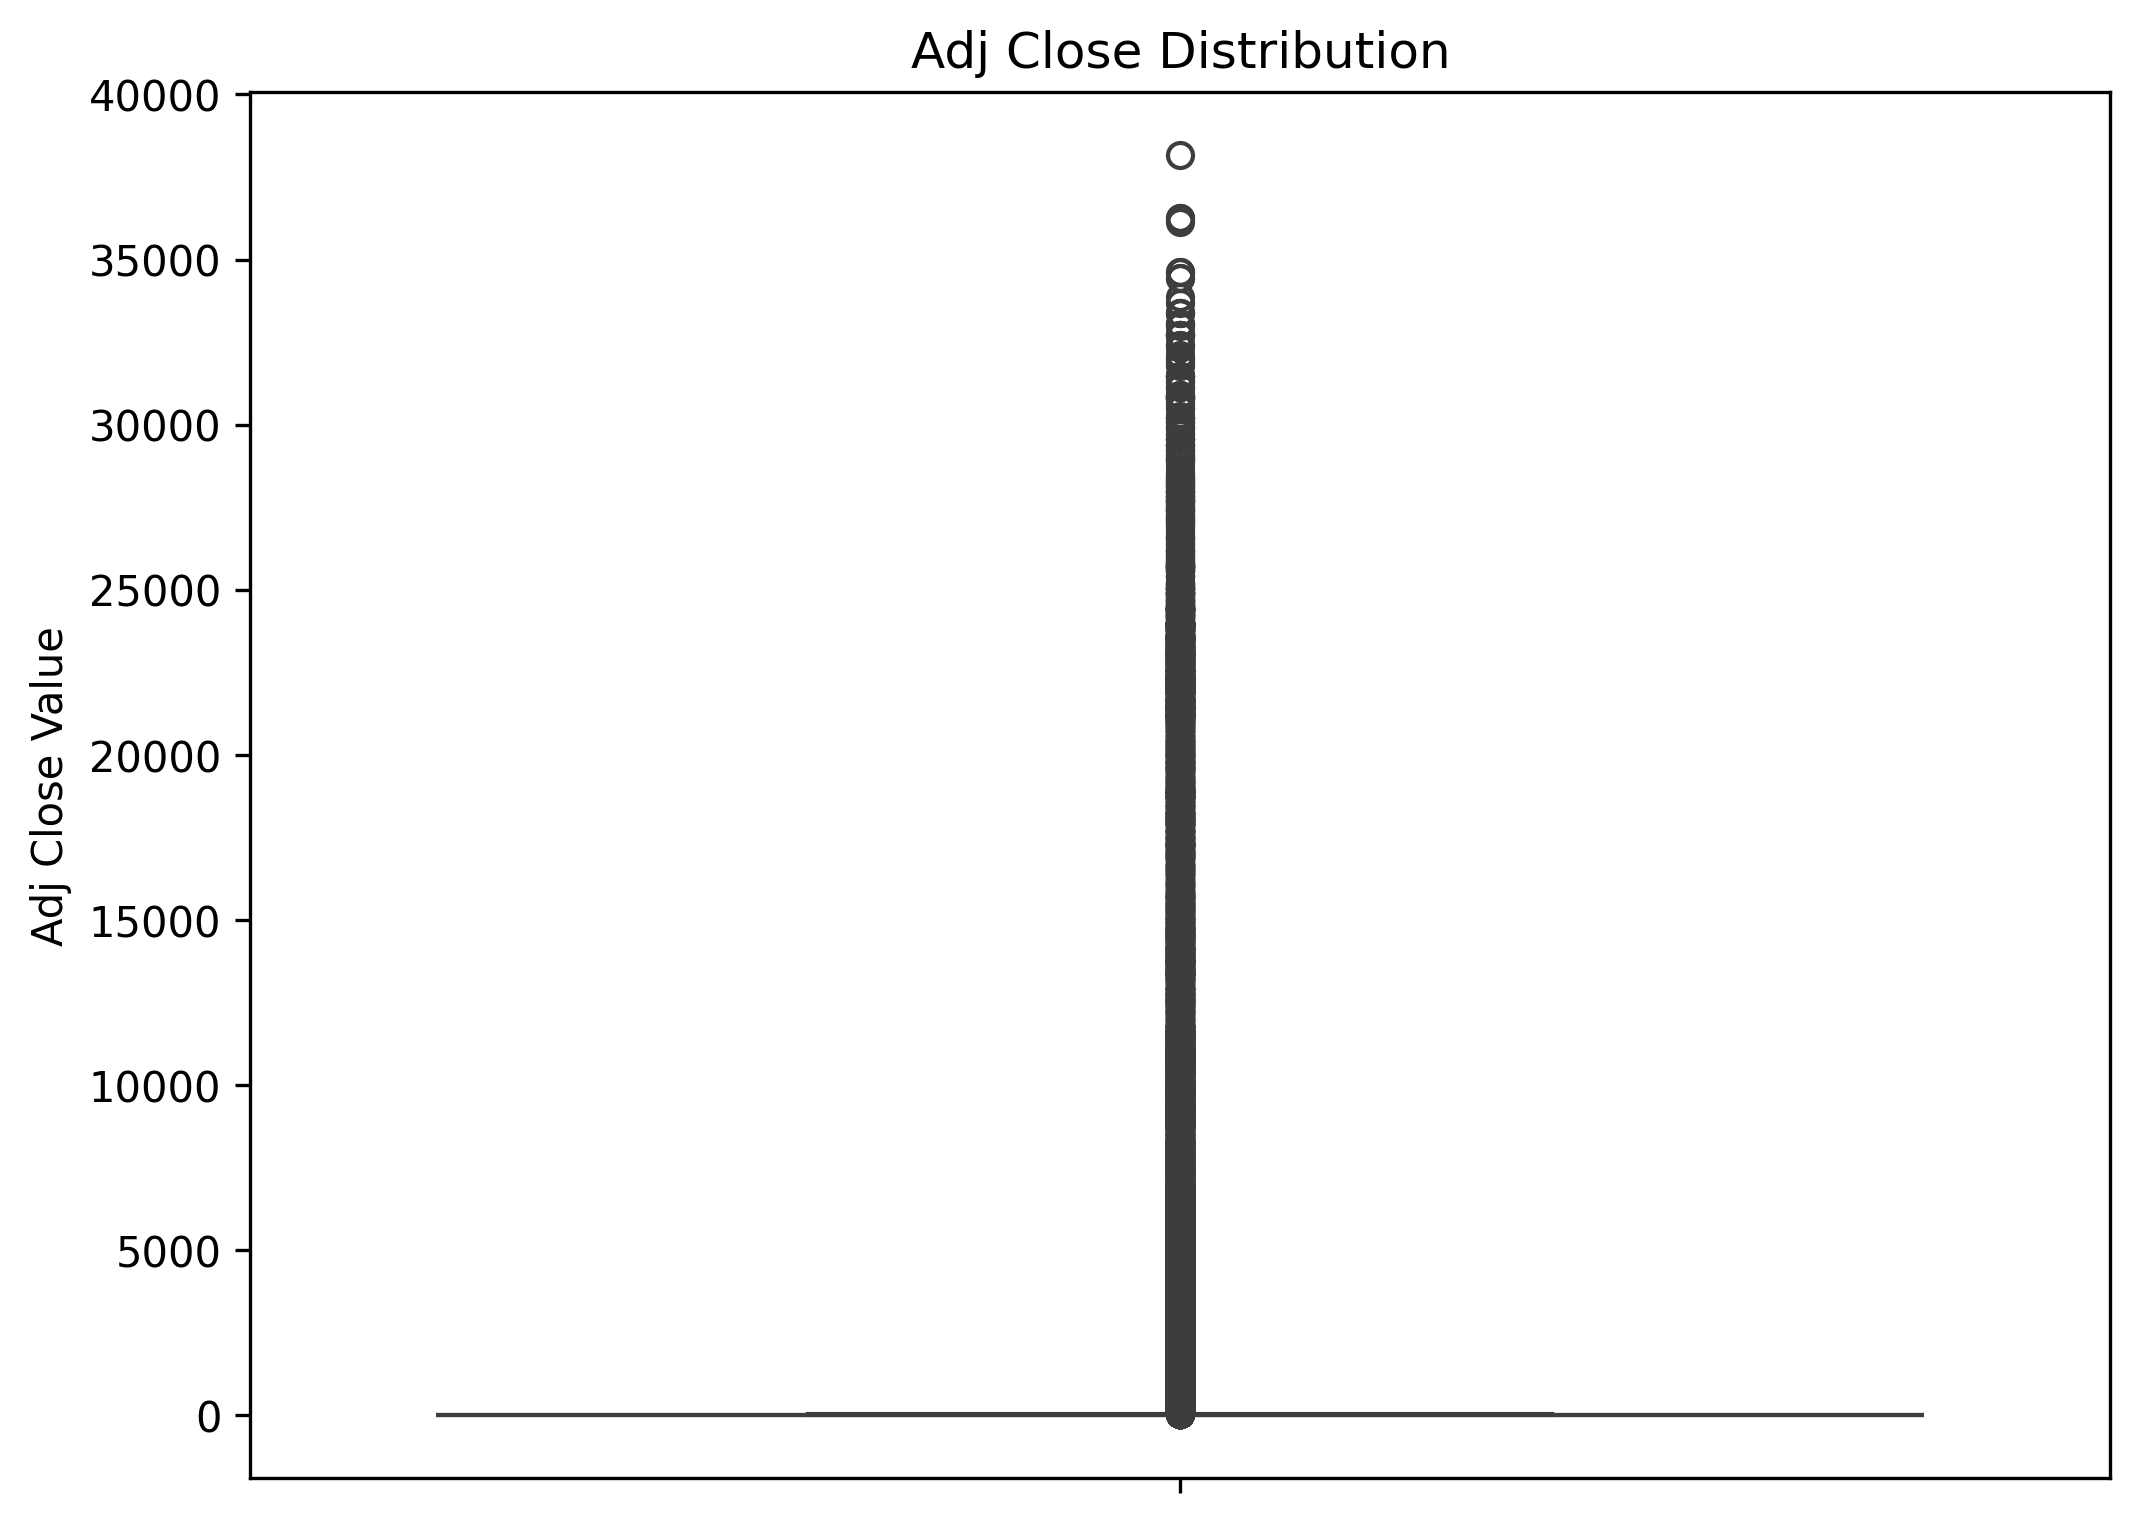

In [4]:
# Compute statistics and eplore the distribution of adj_close variable
compute_statistics(cleaned_df, 'Adj Close')

# Visualisation of the adj_close variable
plot_boxplot(cleaned_df, col_name ="Adj Close", figsize=(8,6))

Summary statistics for 'Volume':

                 Value
count     1.296186e+07
mean      1.116257e+06
std       5.840018e+06
min       1.000000e+00
max       1.855410e+09
skewness  3.127748e+01
kurtosis  2.609091e+03
q25       2.610000e+04
q50       1.365000e+05
q75       5.897000e+05


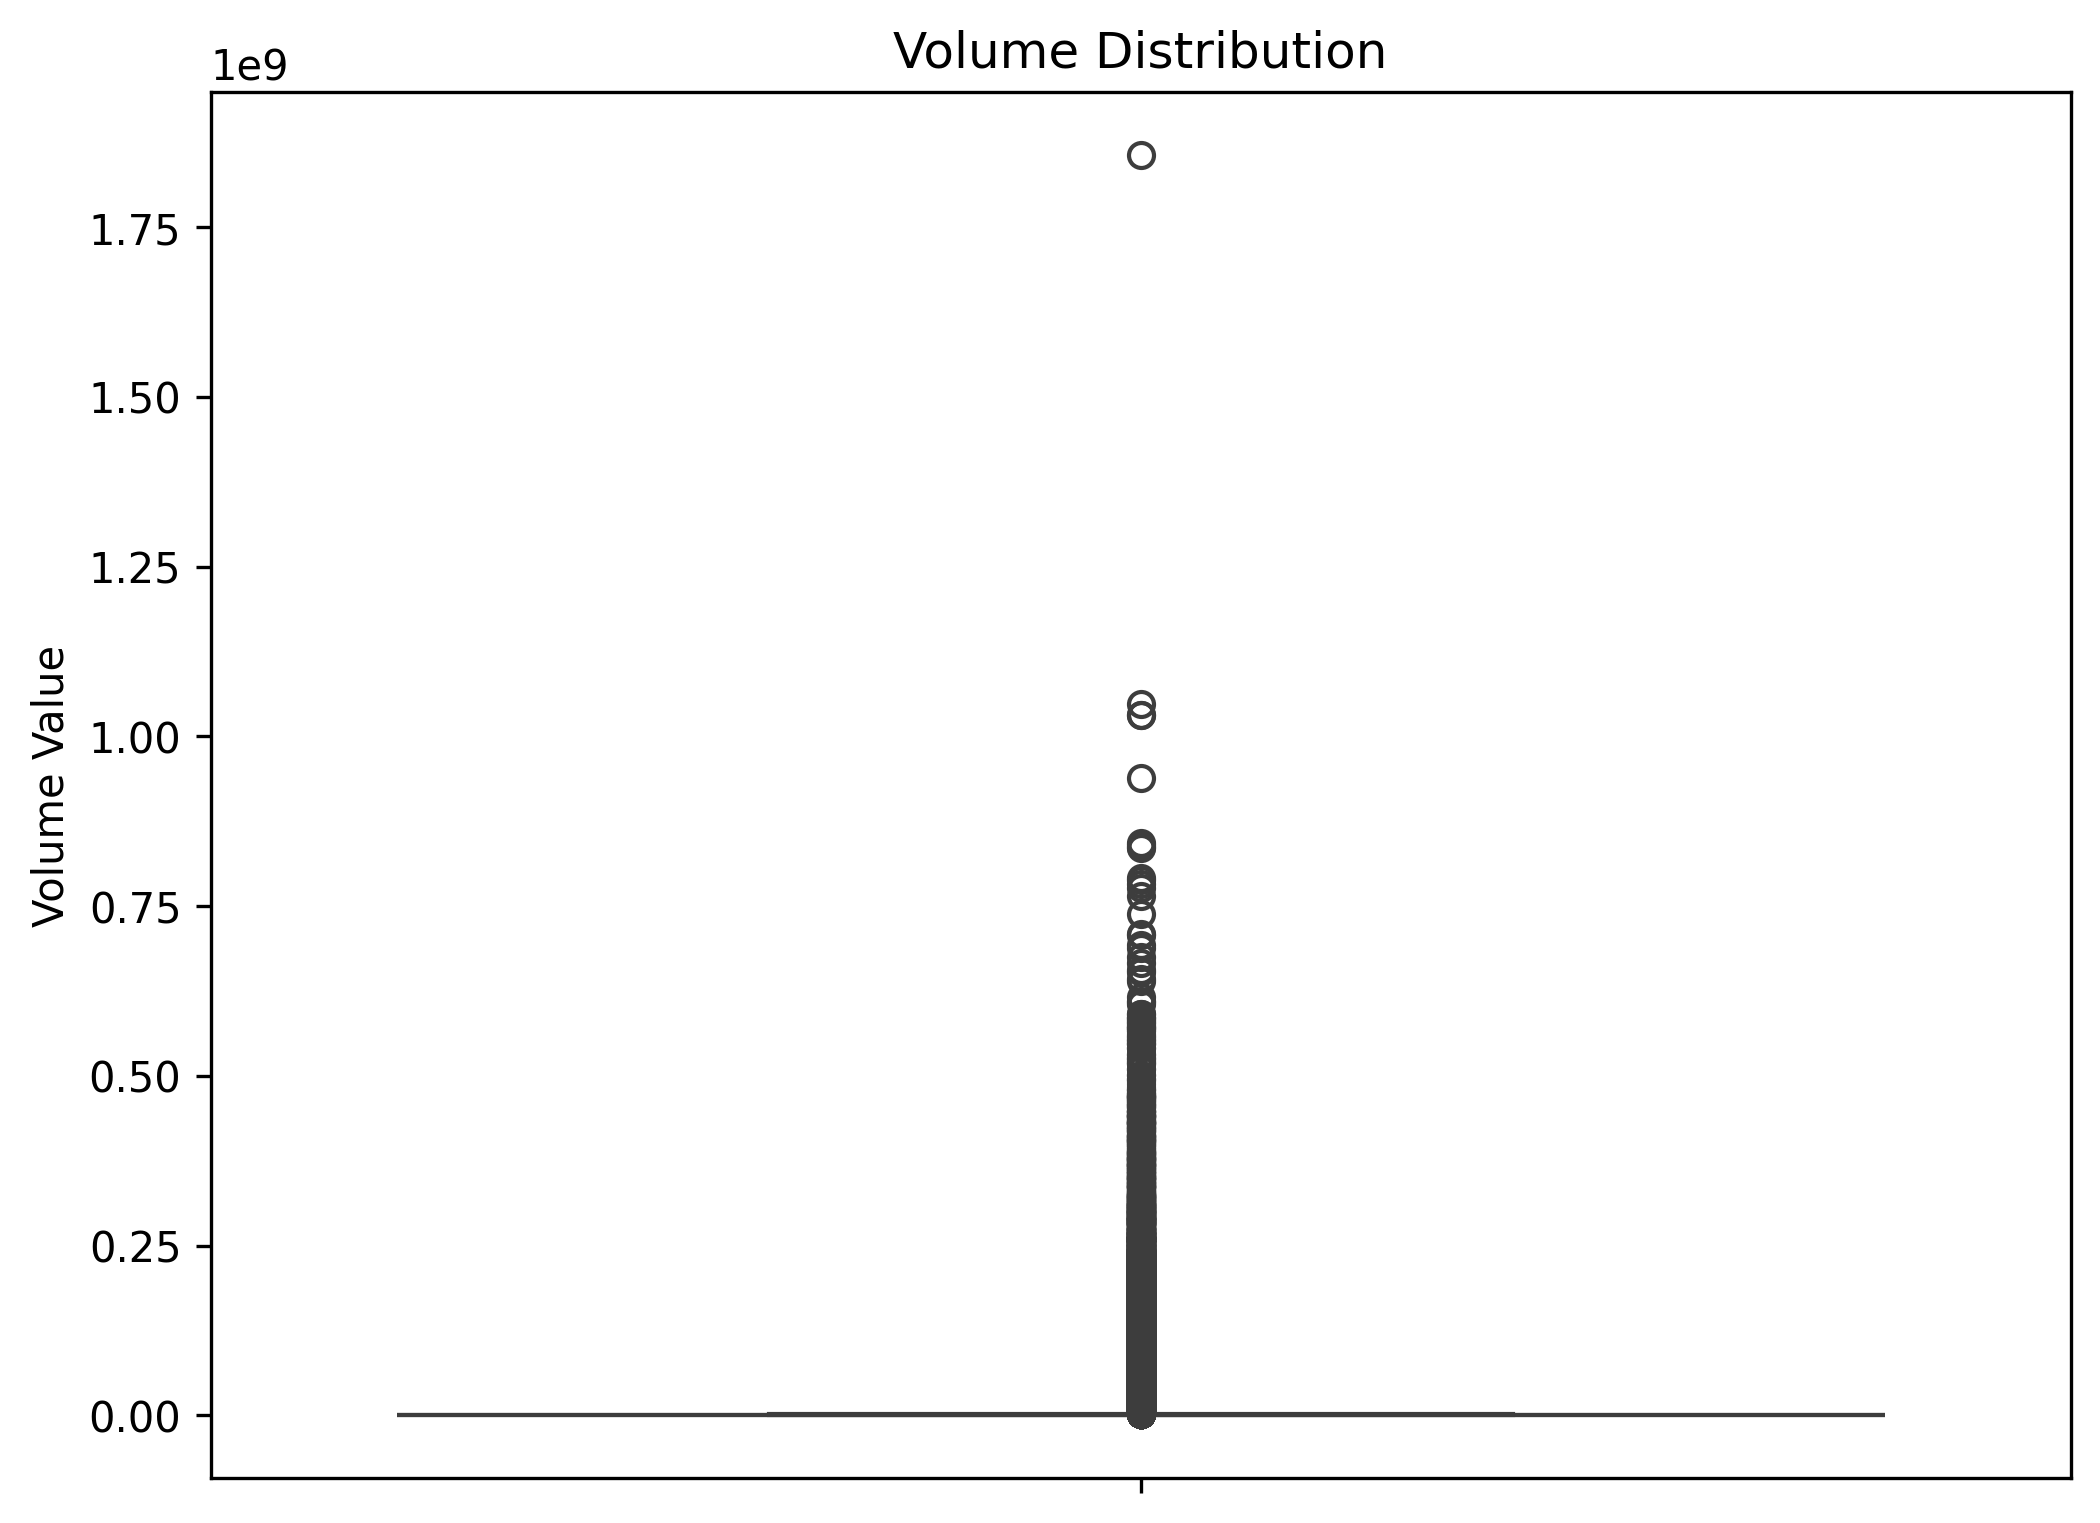

In [5]:
# The same analysis is done for the volume variable:
compute_statistics(cleaned_df, 'Volume')

plot_boxplot(cleaned_df, col_name="Volume", figsize=(8, 6))

Since the distribution of values is strongly skewed for both variables, a logarithmic transformation is applied to normalize the data and reduce the influence of extreme values.

### 2. Compute daily log returns
In this section, the log returns are computed in order to use this feature to compute the volatility of the market.

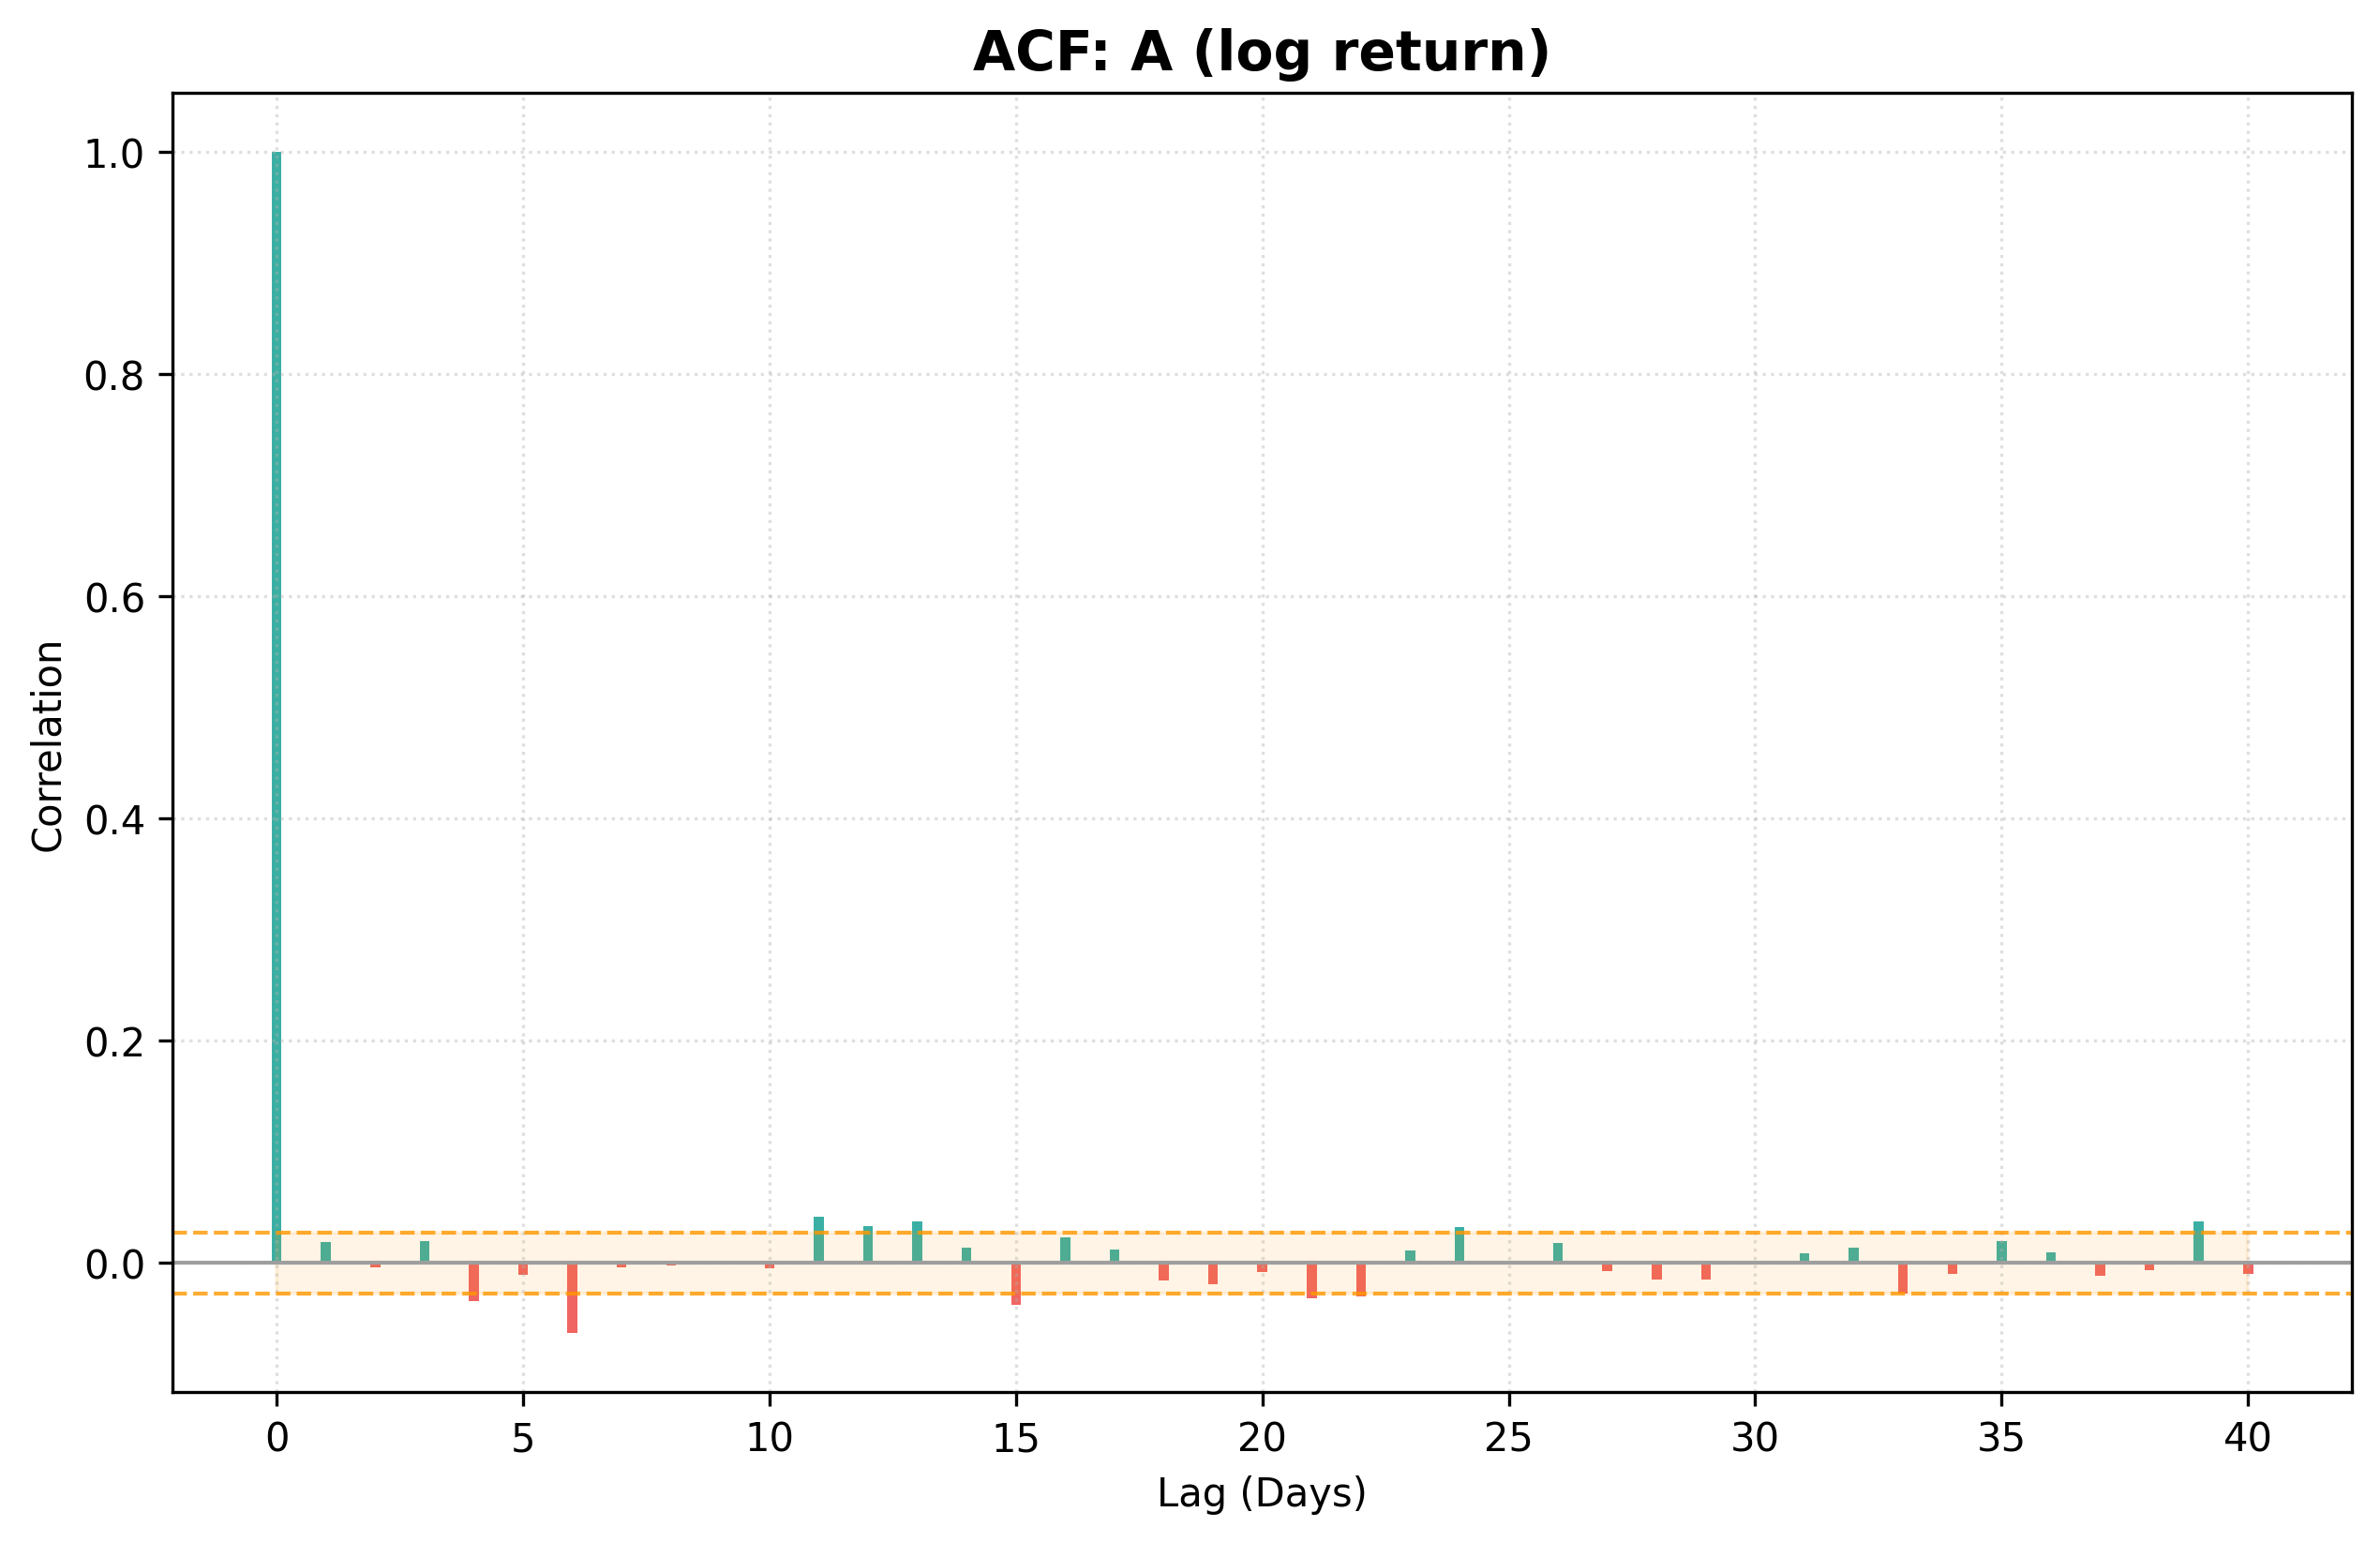

In [6]:
# Compute returns
features_df = compute_daily_returns_unified(cleaned_df)

# Pick the first ticker (e.g., A)
sample_ticker = features_df['ticker'].unique()[0]
plot_acf(features_df, ticker=sample_ticker, return_col='log_return', lags=40)

### 3. Compute market volatility index
Volatility is computed with the previously log returns calculated, this will serve as a potential mood indicator for the next steps.

Displaying Market Volatility Trend...


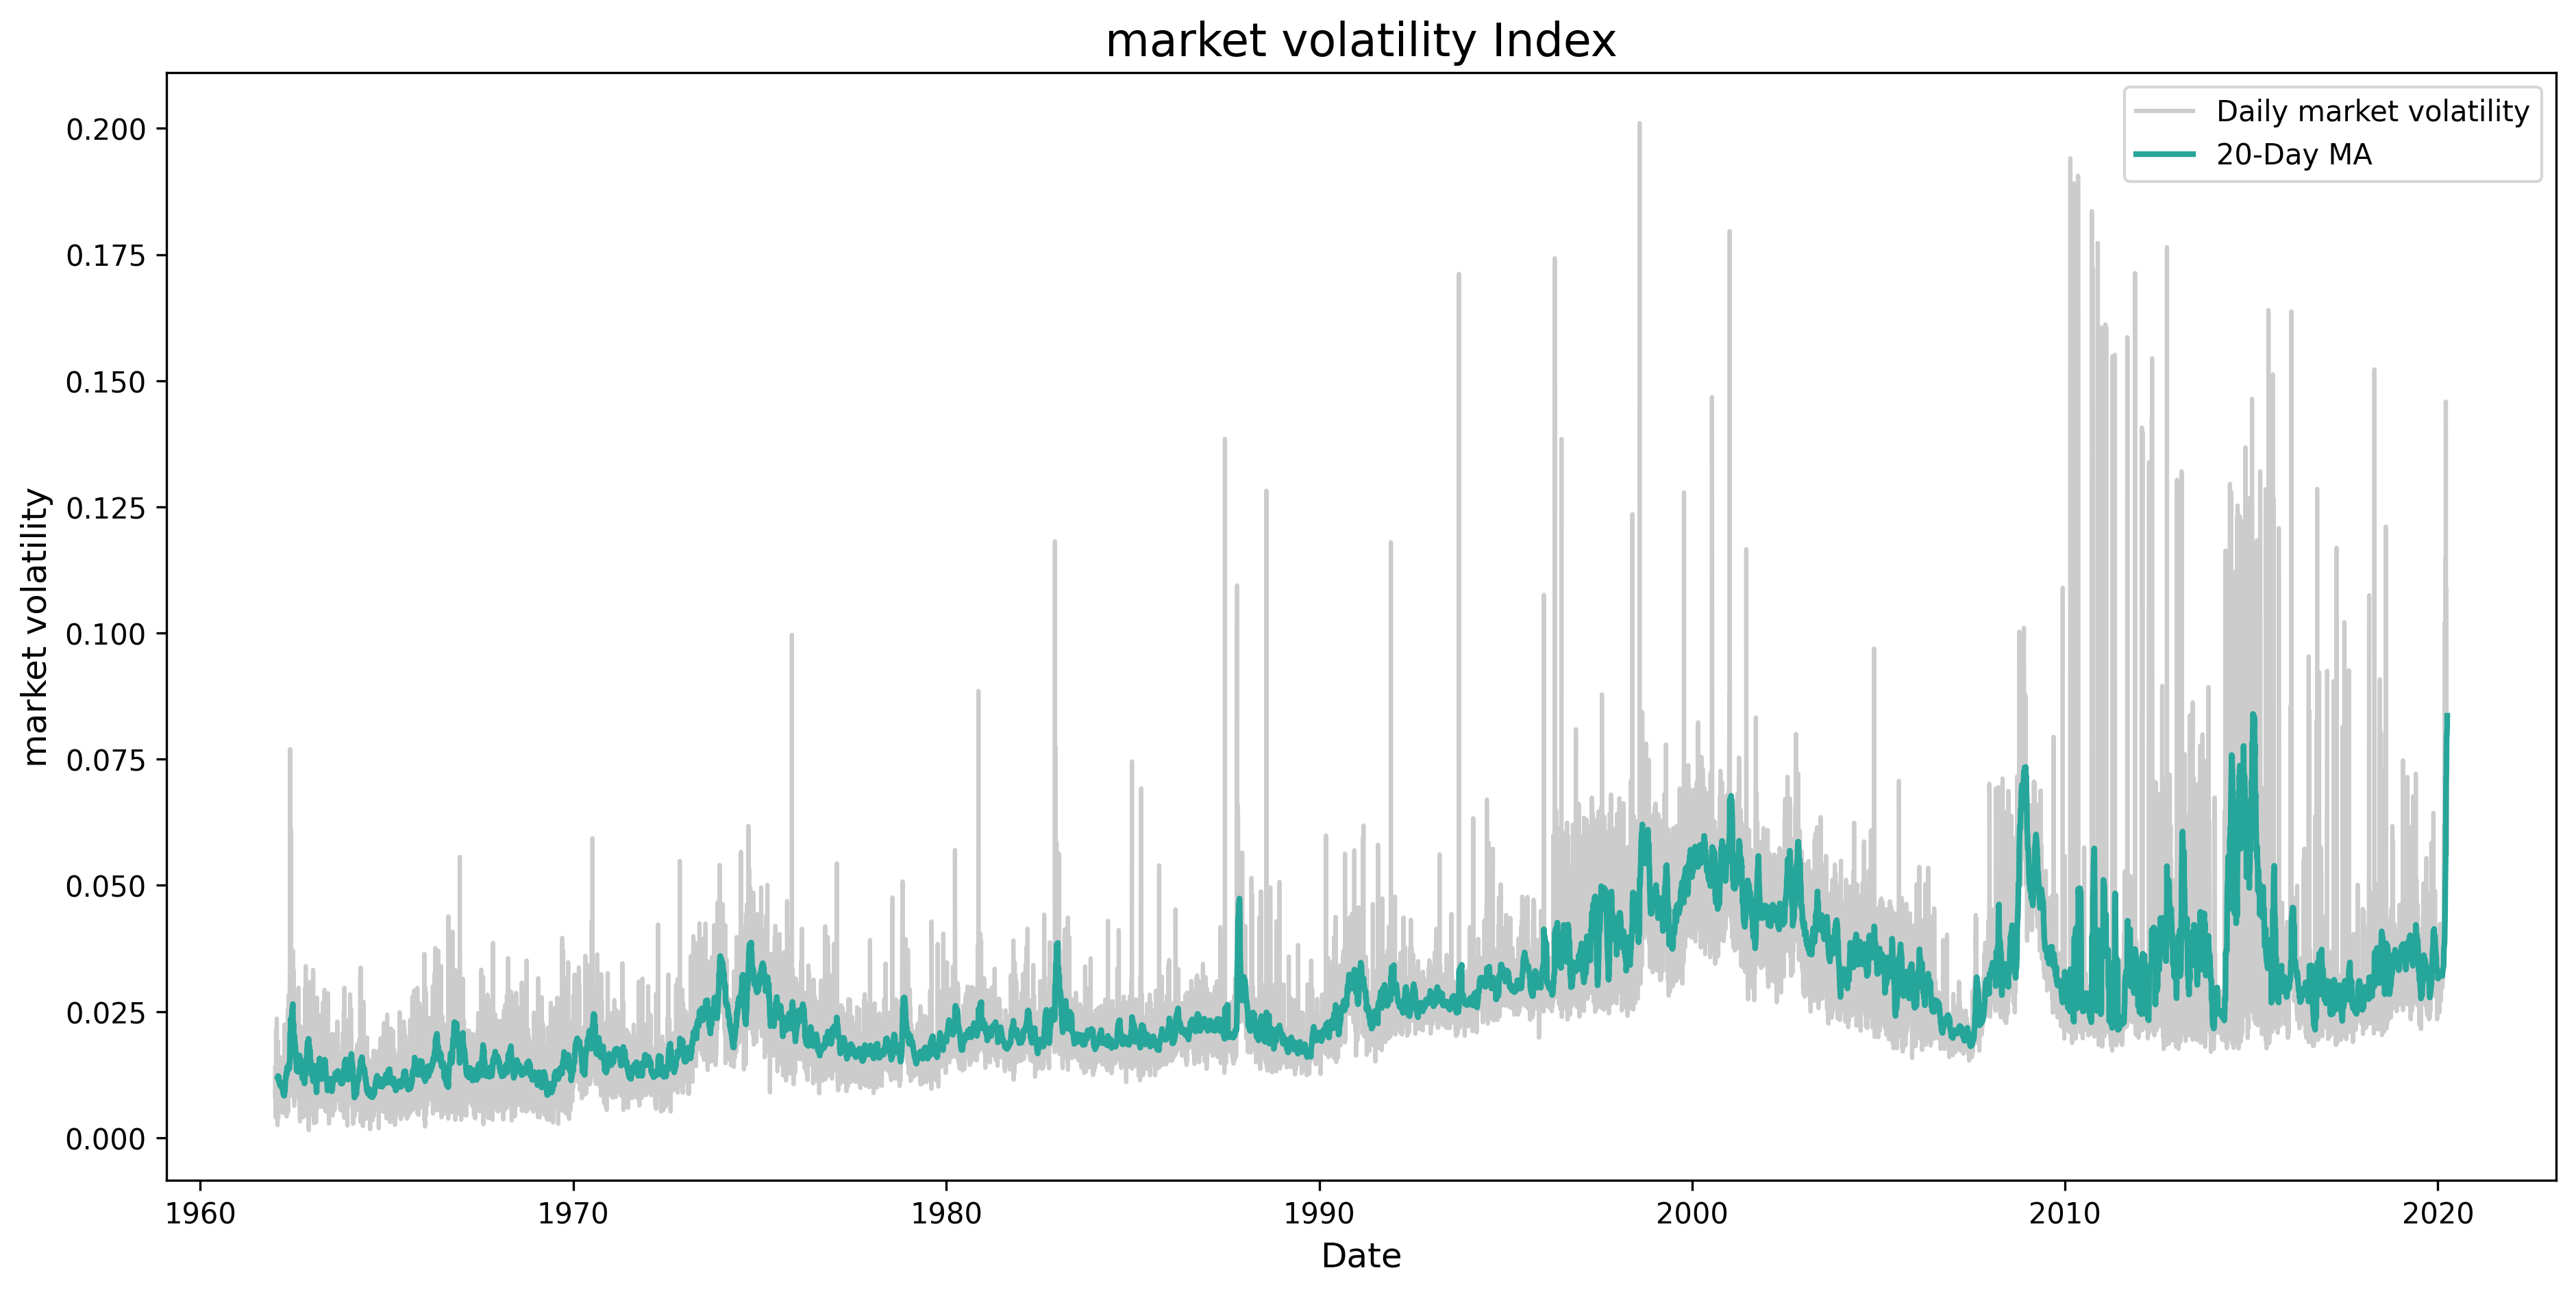

In [7]:
# Compute market volatility
volatility_df = compute_market_volatility_index_unified(features_df)
volatility_df['Date'] = pd.to_datetime(volatility_df['Date']) 
volatility_df.set_index('Date', inplace=True) #taking the date as the index

# Visualize Volatility Trend
print("Displaying Market Volatility Trend...")
plot_market(volatility_df, 'market_volatility', [20])

### 4. Validation of volatility and log returns
The two new features calculated are now analysed to validate them.

Summary statistics for 'log_return':

                 Value
count     1.298980e+07
mean      6.002658e-05
std       4.327512e-02
min      -8.521980e+00
max       8.885303e+00
skewness  6.031113e+00
kurtosis  5.421711e+03
q25      -1.013209e-02
q50       0.000000e+00
q75       1.025649e-02


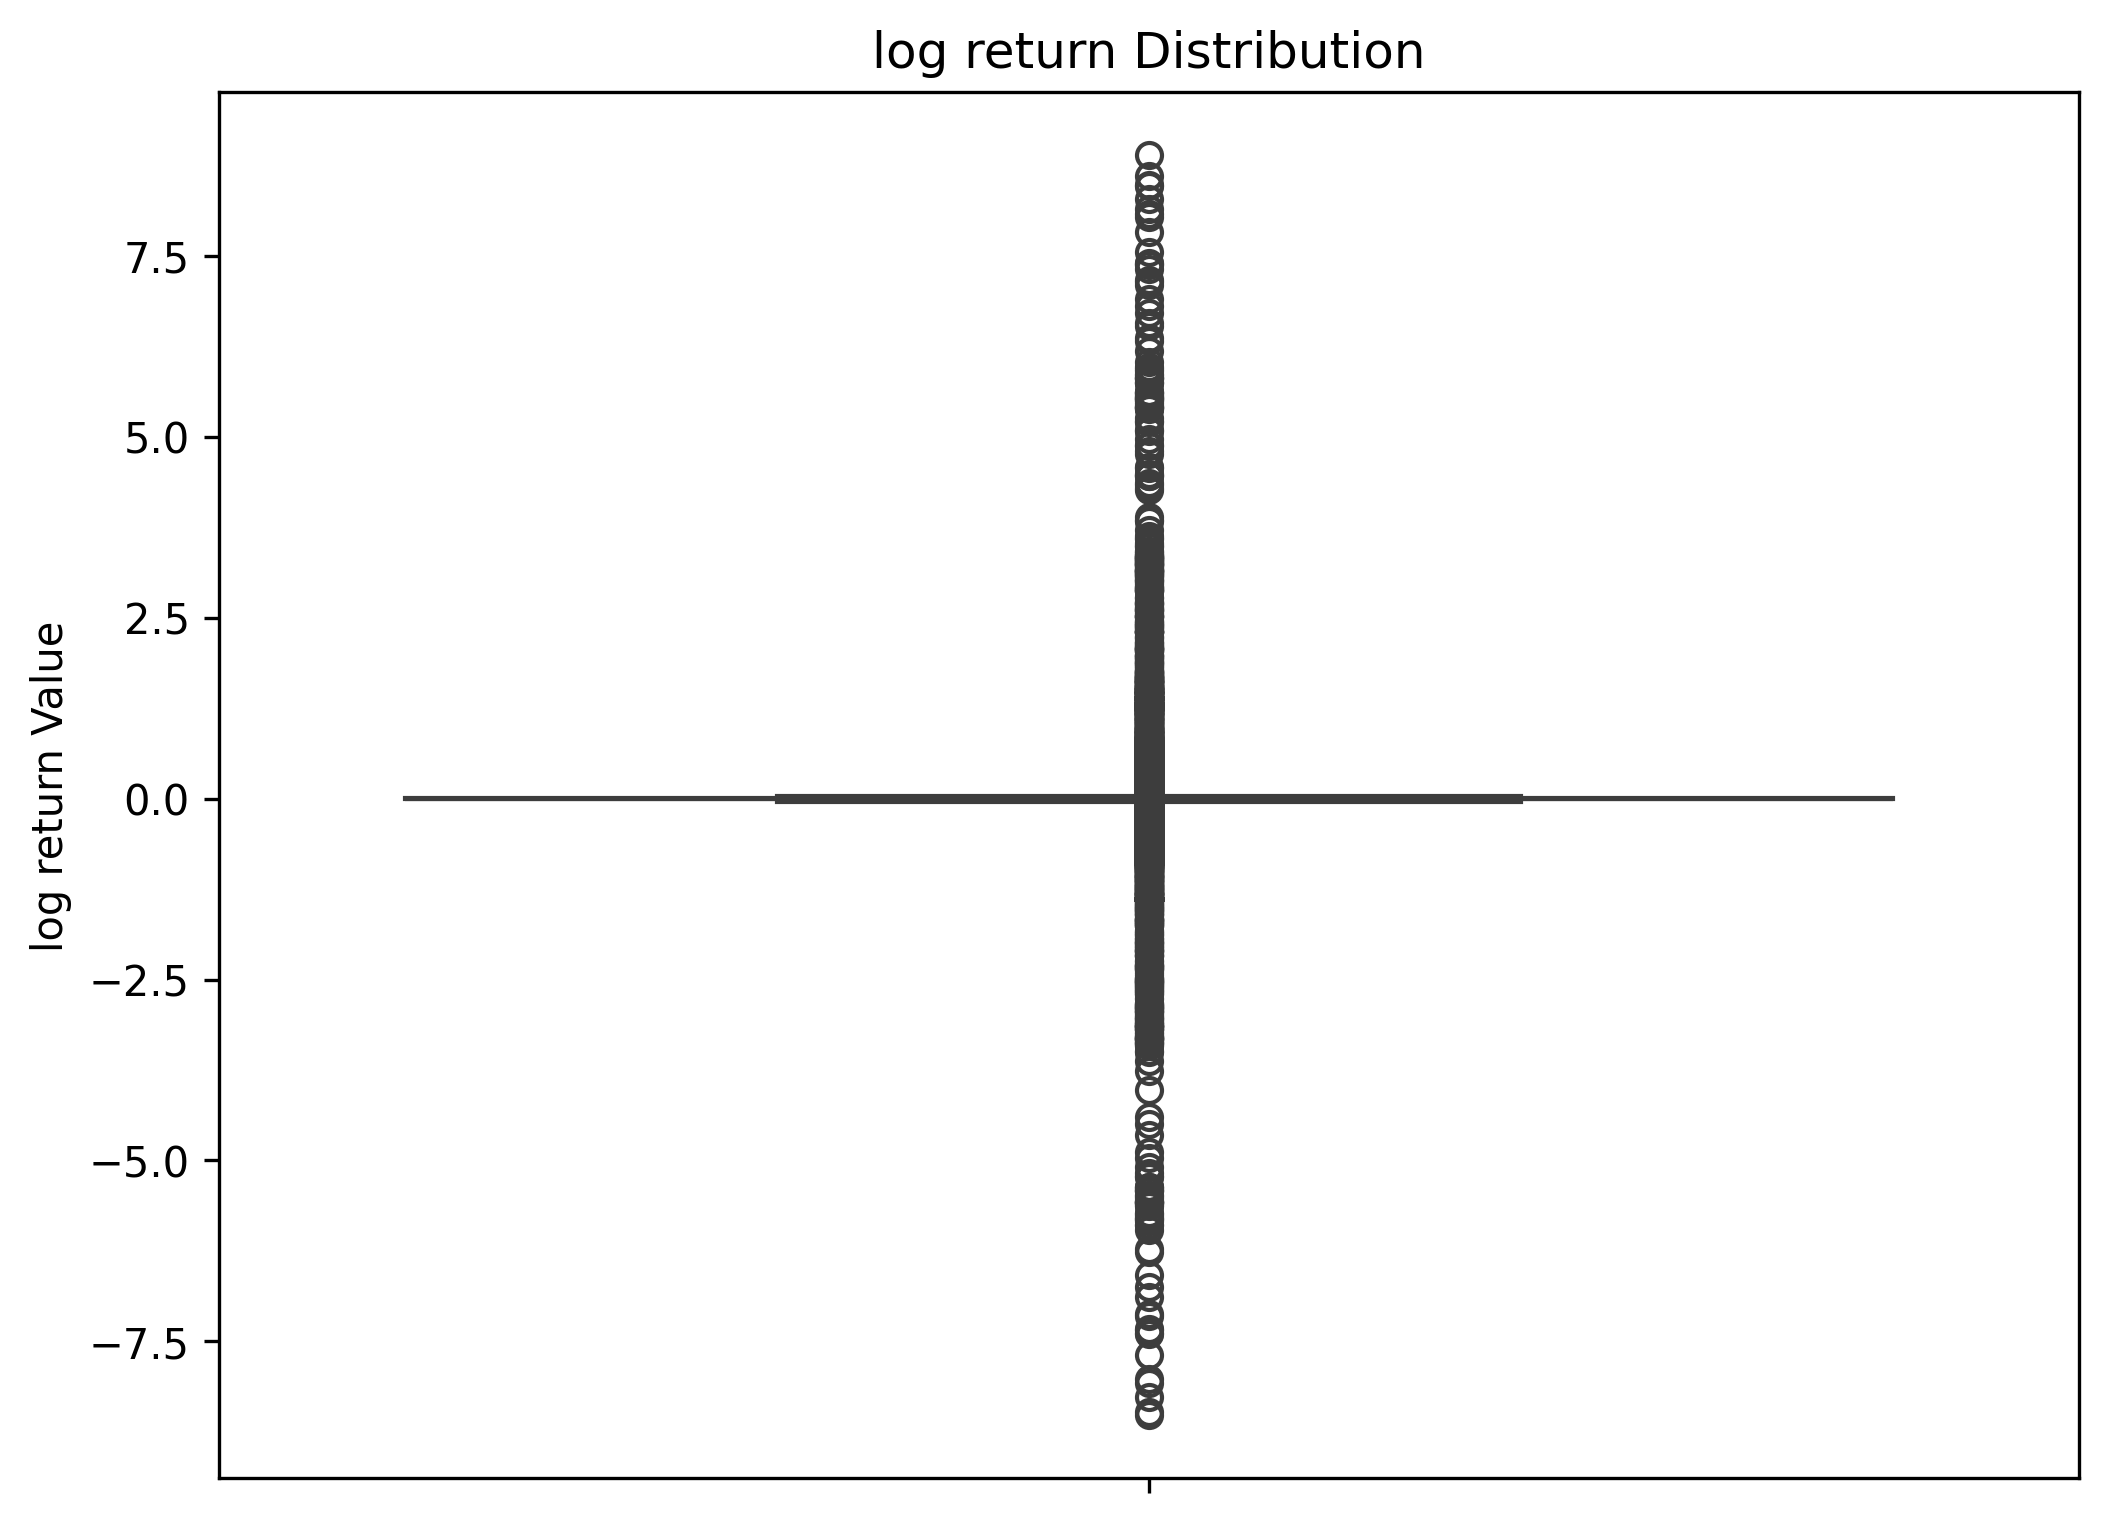

In [8]:
# Validate log returns
compute_statistics(features_df, 'log_return')

# Plot return distribution
plot_boxplot(features_df, col_name="log_return", figsize=(8, 6))

Summary statistics for 'market_volatility':

                 Value
count     14662.000000
mean          0.027755
std           0.017092
min           0.001520
max           0.201049
skewness      2.966643
kurtosis     16.187427
q25           0.017957
q50           0.023981
q75           0.031991


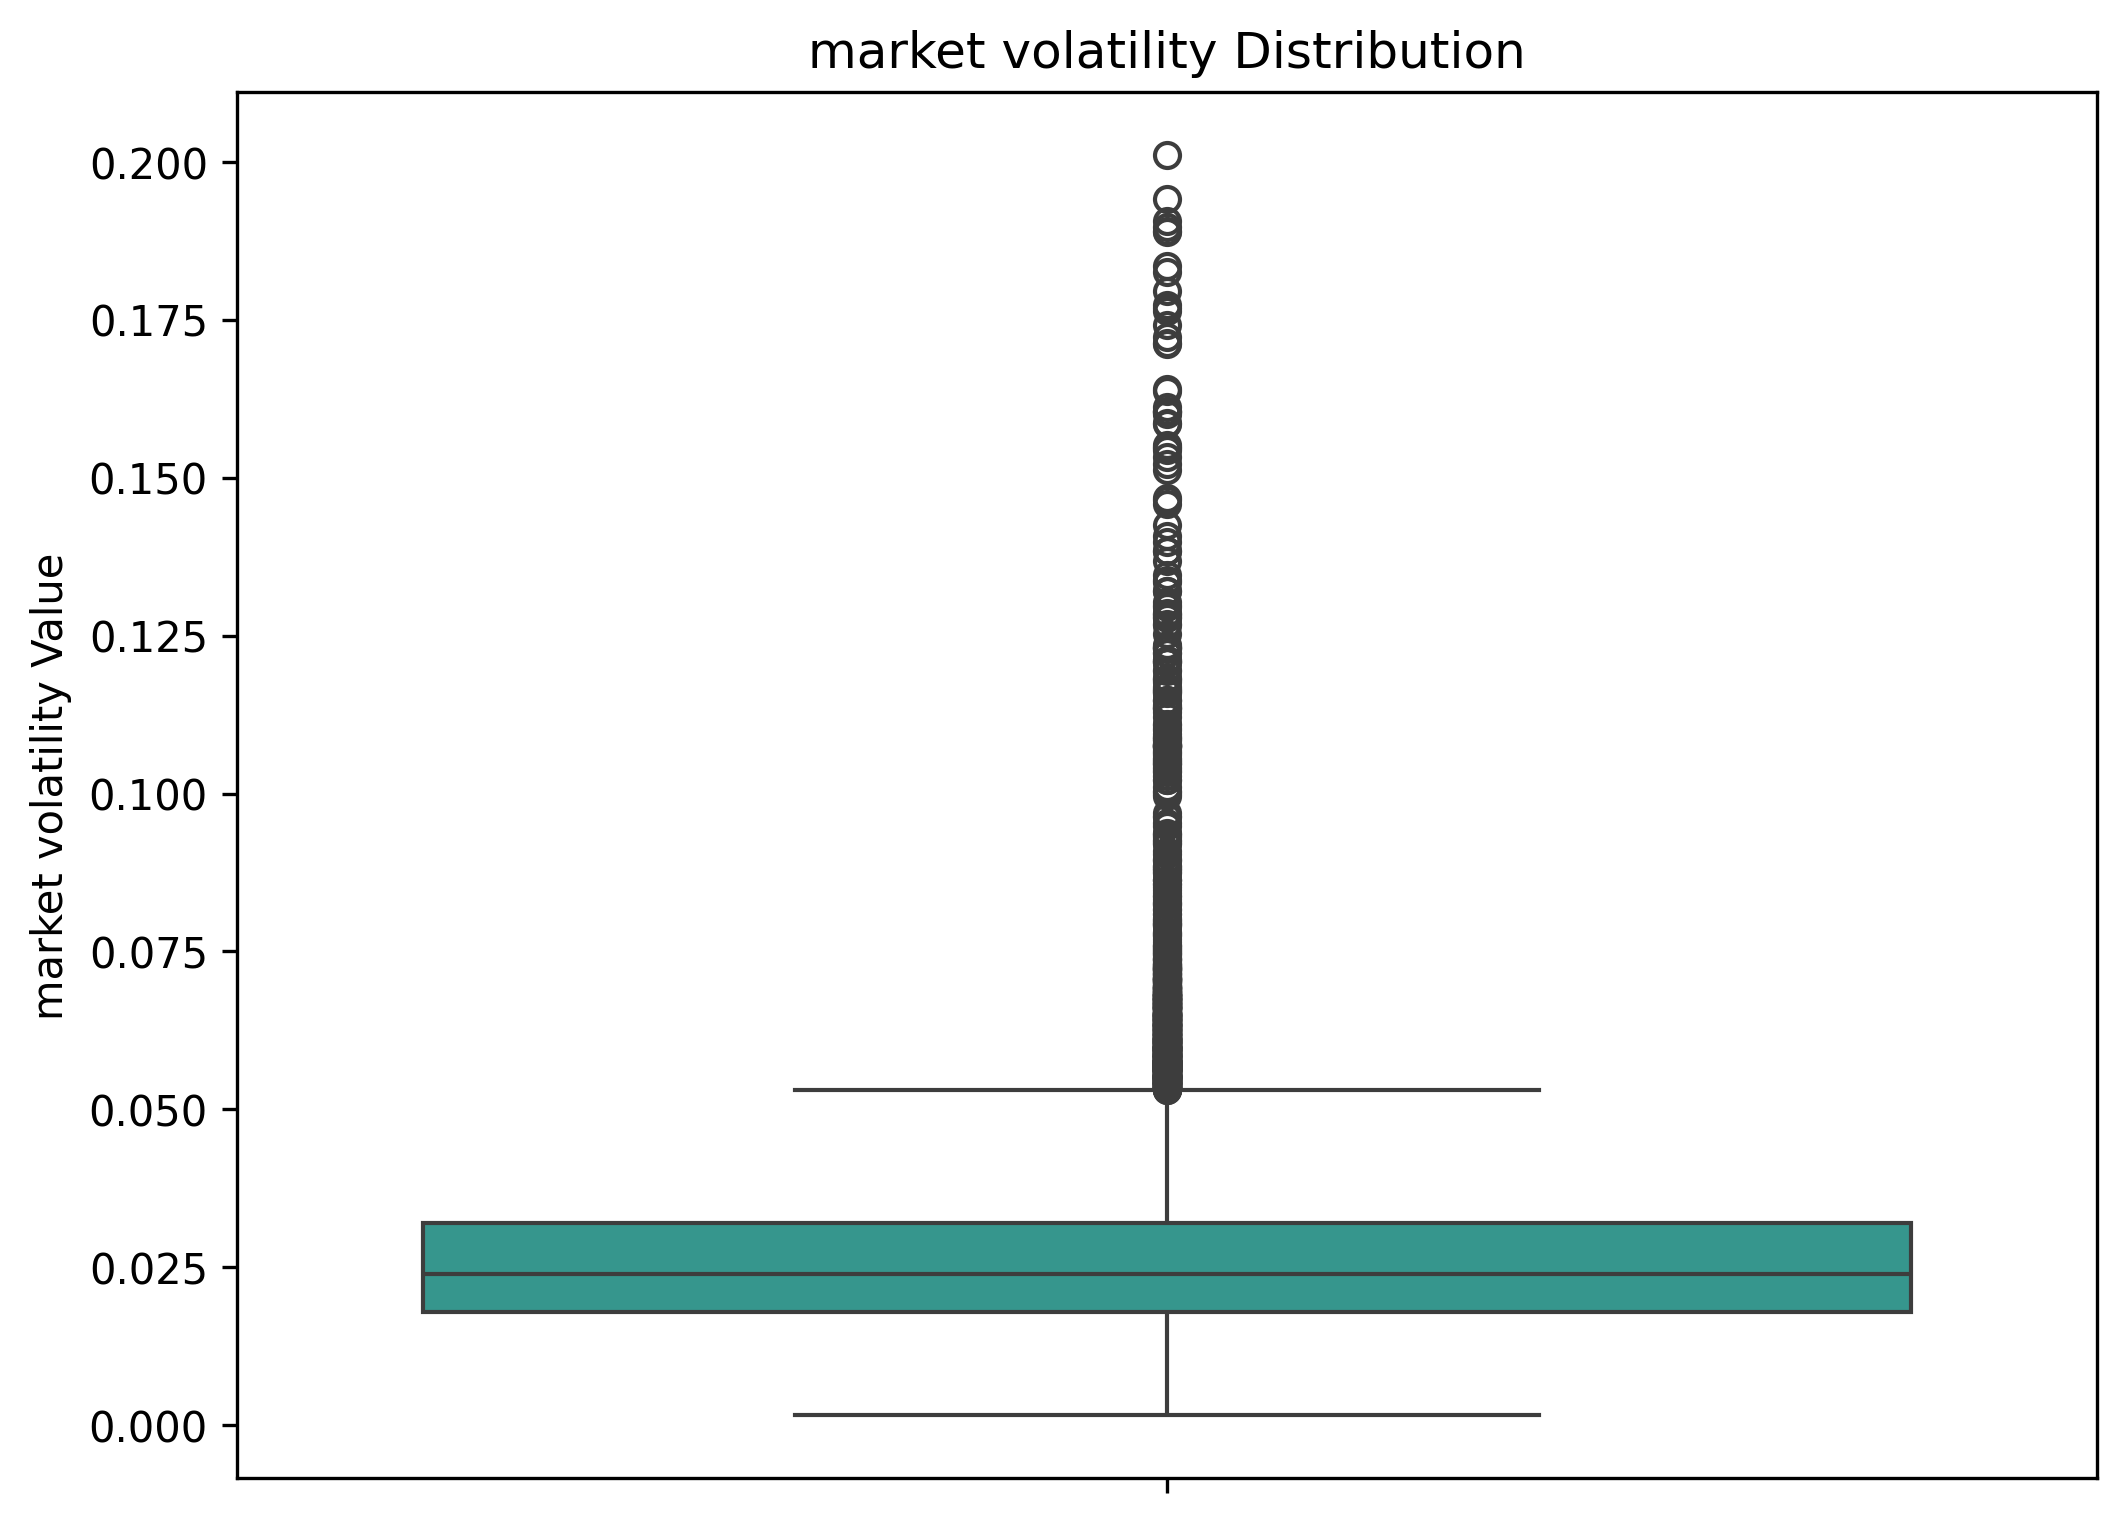

In [9]:
# Validate volatility 
compute_statistics(volatility_df, 'market_volatility')

# Plot volatility distribution
plot_boxplot(volatility_df, col_name="market_volatility", figsize=(8, 6))

The boxplot visualization confirms that the logarithmic transformation has successfully reduced the skewness of the data and mitigated the influence of extreme values. The following step will now apply further preprocessing to refine the feature distribution.

### 5. Experiment with Smoothing Windows
Different smoothing window sizes are tested to capture short and longterm fluctuations in volatility, allowing a better understanding of how sensitive the measure is to recent versus extended market movements.

            market_volatility  volatility_ma_5d  volatility_ma_10d  \
Date                                                                 
1962-02-07           0.014064          0.009987           0.010407   
1962-02-08           0.011496          0.008475           0.010043   
1962-02-09           0.008207          0.009316           0.010614   
1962-02-12           0.008664          0.009702           0.010257   
1962-02-13           0.014897          0.011465           0.010609   
1962-02-14           0.009064          0.010465           0.010226   
1962-02-15           0.013206          0.010807           0.009641   
1962-02-16           0.012643          0.011695           0.010506   
1962-02-19           0.007300          0.011422           0.010562   
1962-02-20           0.006081          0.009659           0.010562   
1962-02-21           0.011421          0.010130           0.010298   

            volatility_ma_20d  volatility_ma_30d  
Date                                  

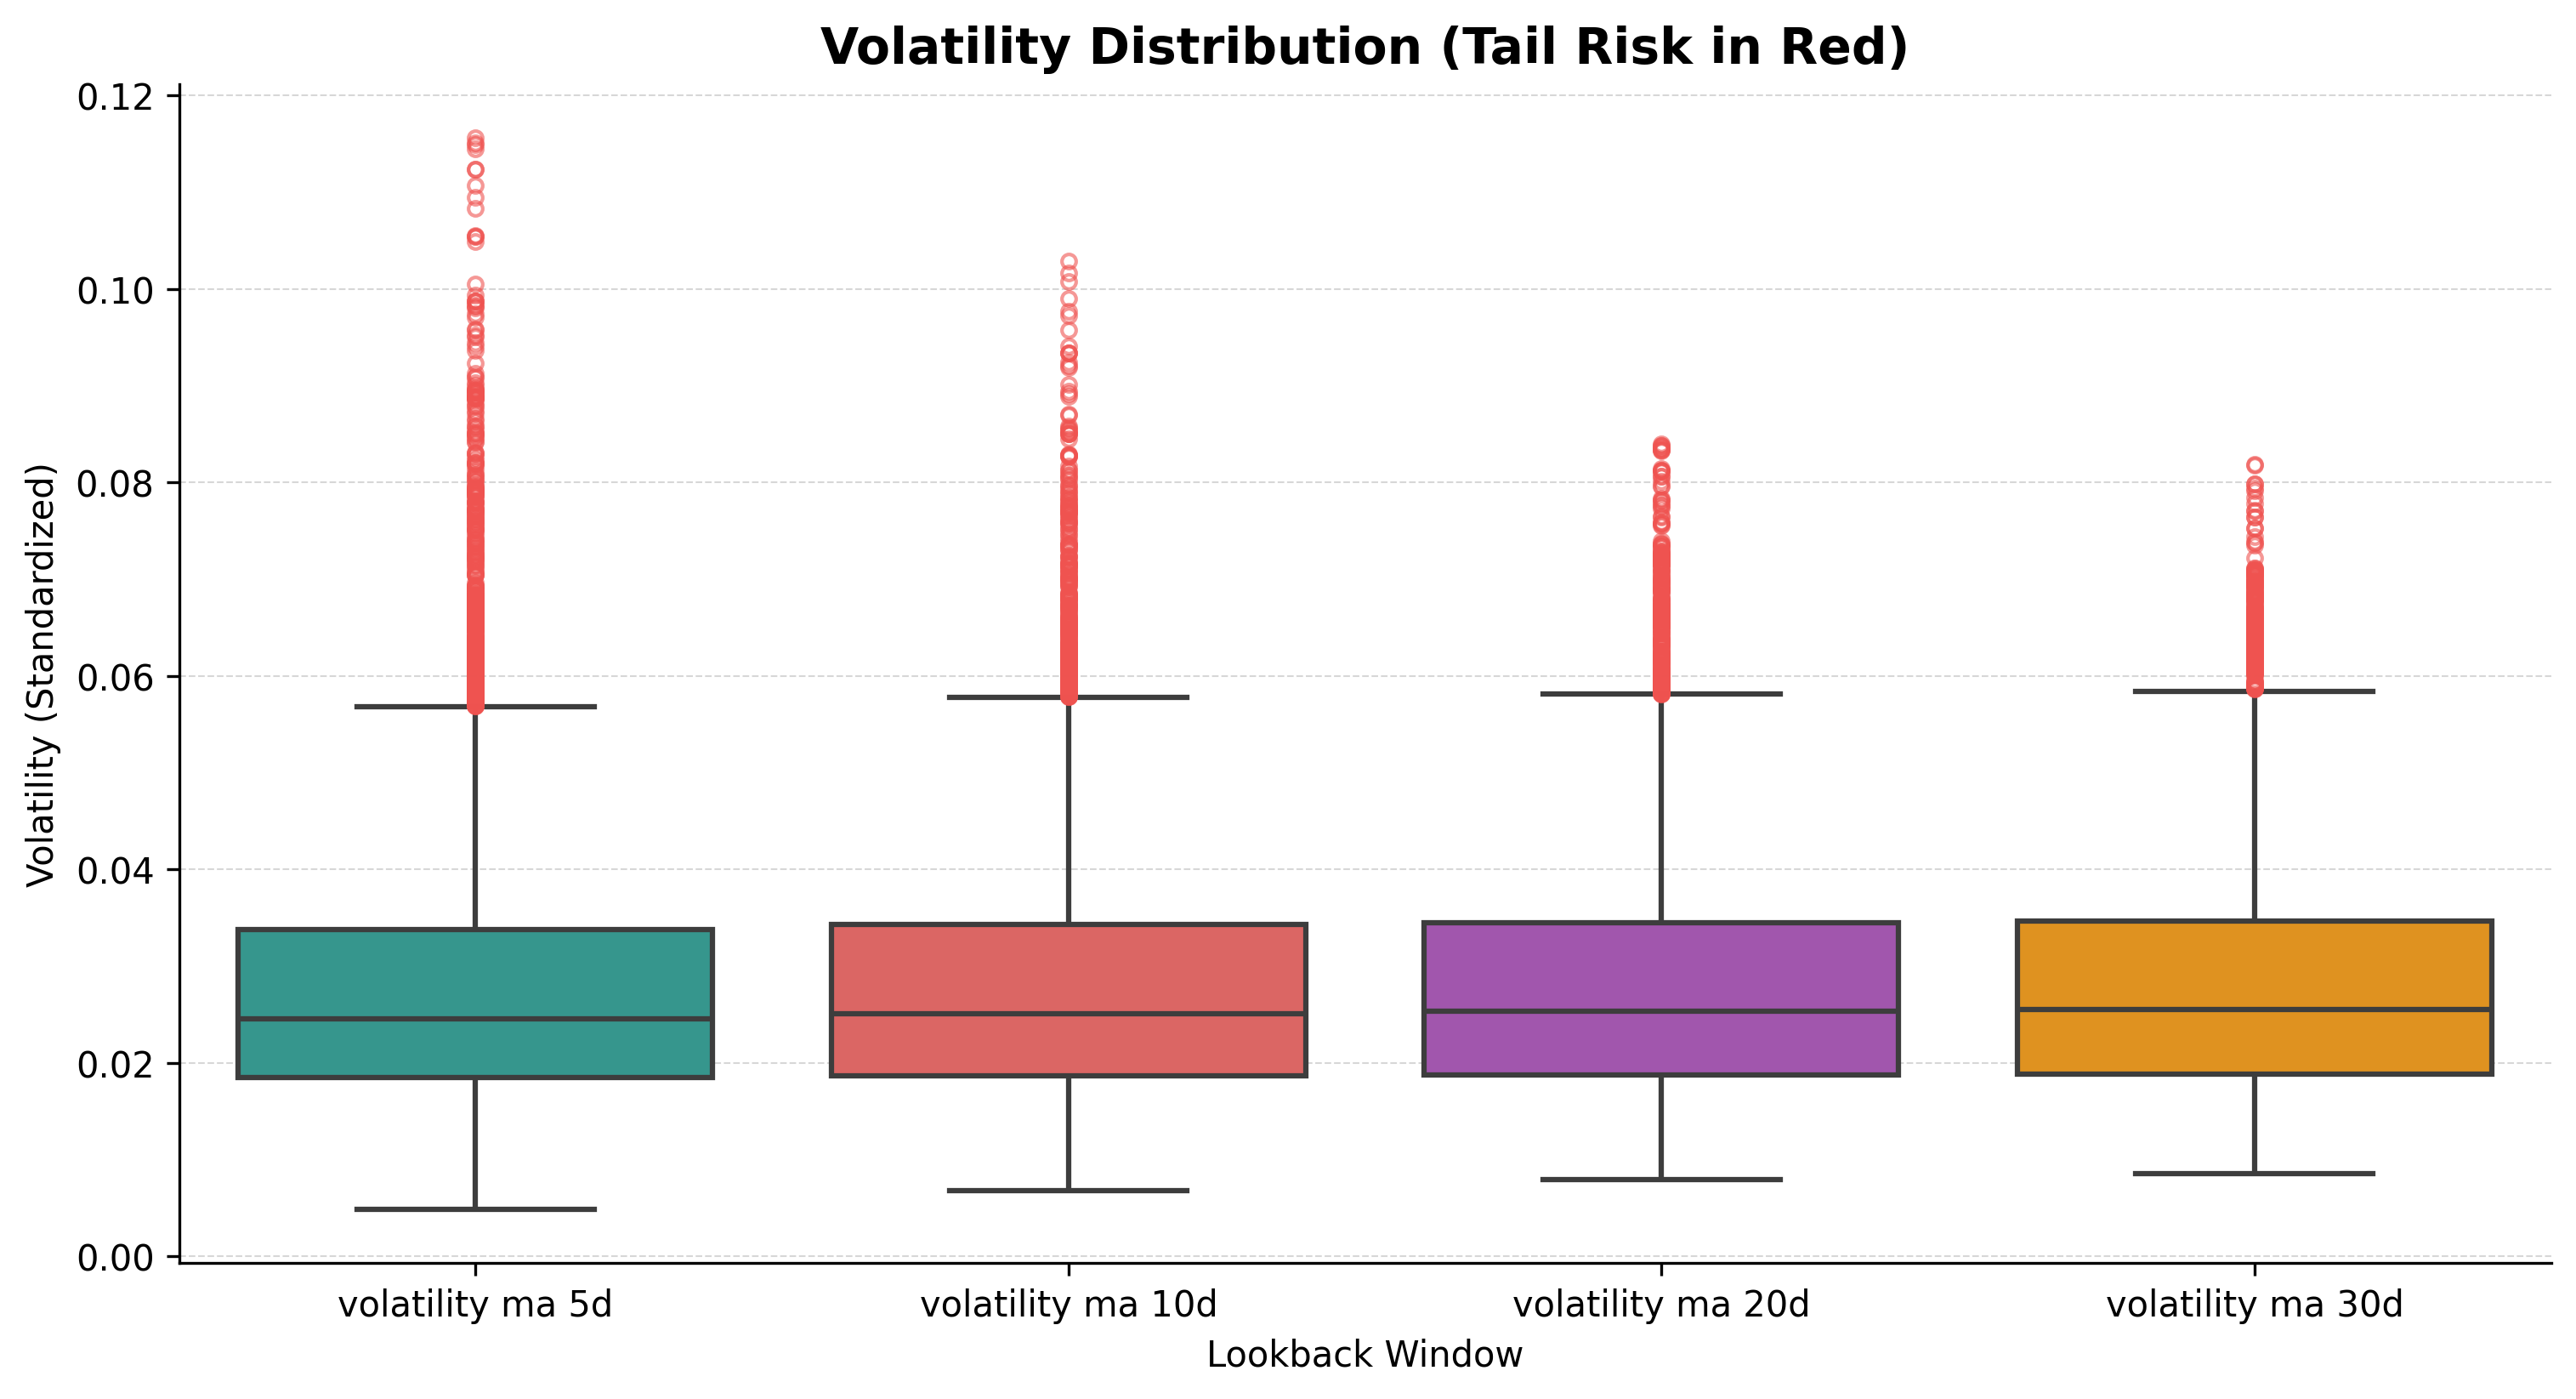

In [10]:
# Compute window over 5, 10, 20, and 30 days windows
smoothed_df = compute_smoothed_volatility(volatility_df)
print(smoothed_df.iloc[25:36])

assess_smoothed_volatility(smoothed_df)

# Plot volatility distribution for different days windows
plot_volatility_comparison(smoothed_df, vol_cols=("volatility_ma_5d", "volatility_ma_10d", "volatility_ma_20d", "volatility_ma_30d"))

A 20-day smoothing window is selected as it provides a good balance between noise reduction and signal preservation. The autocorrelation increases consistently with larger windows, indicating smoother and more persistent trends, while the variance reduction also improves. However, beyond 20 days, the marginal gain in variance reduction becomes small, suggesting that longer windows would excessively smooth the data and obscure relevant short-term fluctuations.

### 6. Compute “Mood” Indicators
The following section computes several daily time-series indicators that describe the overall state of the market. These indicators will serve as features for a K-Means clustering algorithm to identify distinct market regimes.

#### 1. Log Returns ($r_{t}$)
We use logarithmic returns instead of simple returns because they are additive over time and typically follow a more normal distribution, which is beneficial for statistical modeling.

$$r_{i,t} = \ln\left(\frac{P_{i,t}}{P_{i,t-1}}\right)$$

Where:
* $P_{i,t}$ is the Adjusted Close price of stock $i$ at time $t$.

#### 2. Market Direction ($\bar{r}_t$)
Measures the average daily trend of the market. A positive value indicates a generally bullish day, while a negative value indicates a bearish day. It is defined as the cross-sectional mean of log returns for all active tickers on day $t$.

$$\text{Direction}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} r_{i,t}$$

Where:
* $N_t$ is the number of active tickers on day $t$.

#### 3. Market Volume ($\Delta \bar{v}_t$)
Captures the aggregate change in trading activity. This indicator measures the average daily change in log-volume across all stocks, providing insight into the conviction or intensity behind market moves.

$$\text{Volume Change}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} \left( \ln(V_{i,t}) - \ln(V_{i,t-1}) \right)$$

Where:
* $V_{i,t}$ is the trading volume of stock $i$ at time $t$.

#### 4. Market Correlation ($\rho_t$)
Gauges market cohesion or systemic risk. This indicator calculates the mean pairwise correlation of stock returns over a rolling window (e.g., 30 days). High correlation implies stocks are moving in unison (often associated with panic or "risk-off" sentiment), while low correlation indicates stock-specific factors are dominant ("risk-on").

For computational efficiency on large universes, we estimate this using a dynamic random sample of tickers ($S$) rather than the full population:

$$\text{Correlation}_t = \frac{1}{|S|(|S|-1)} \sum_{i \in S} \sum_{j \in S, j \neq i} \text{Corr}(r_{i}, r_{j})_{[t-w, t]}$$

Where:
* $w$ is the rolling window size (e.g., 30 days).
* $\text{Corr}(r_i, r_j)$ is the Pearson correlation coefficient between the return series of stock $i$ and stock $j$ over the window.

#### 5. Market Breadth ($B_t$)
Measures participation in the market's trend. It is calculated as the ratio of stocks exhibiting positive momentum (positive log return) to the total number of active stocks for that day. A high value indicates a broad, healthy rally.

$$B_t = \frac{\sum_{i=1}^{N_t} \mathbb{I}(r_{i,t} > 0)}{N_t}$$

Where:
* $\mathbb{I}(\cdot)$ is the indicator function, equal to 1 if the condition is true and 0 otherwise.

#### 6. Market Intra-day Volatility (Normalized ATR)
Quantifies daily market "nervousness" or instability. This indicator is the cross-sectional average of each stock's Normalized True Range.

First, the **True Range ($TR$)** captures the full daily price movement, including overnight gaps:

$$TR_{i,t} = \max \left( H_{i,t} - L_{i,t}, \left| H_{i,t} - C_{i,t-1} \right|, \left| L_{i,t} - C_{i,t-1} \right| \right)$$

To make it comparable across stocks of different prices, we normalize it by the previous close price:

$$\text{NormTR}_{i,t} = \frac{TR_{i,t}}{C_{i,t-1}}$$

The market-wide indicator is the average of these normalized values:

$$\text{Market ATR}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} \text{NormTR}_{i,t}$$

Where:
* $H_{i,t}, L_{i,t}, C_{i,t}$ are the High, Low, and Close prices for stock $i$ at time $t$.

In [11]:
# Market Regime Indicators Calculation 

# Market Direction: Measures the average daily trend of the market.
# A positive value indicates a bullish day, while a negative value indicates a bearish day.
direction_df = compute_market_direction_unified(features_df)

# Market Volume: Captures the change in trading activity.
# This indicator measures the average daily change in log-volume across all stocks,
# providing insight into the conviction behind market moves.
volume_df = compute_market_volume_unified(features_df)

# Market Correlation: Gauges market cohesion.
# This indicator calculates the mean pairwise correlation of stock returns over a 
# 30-day rolling window. A high value suggests stocks are moving in unison (risk-off sentiment),
# while a low value indicates that stock-specific factors are dominant (risk-on).
#
# For computational efficiency on a large universe of stocks, the calculation is
# performed on a dynamic random sample of 100 tickers that were actively trading 
# during each specific window.
correlation_df = compute_market_correlation_dynamic(
    df=features_df, 
    window=30, 
    sample_size=100
)

# Market Breadth: Measures the participation in the market's trend.
# It is calculated as the percentage of stocks with a positive log return each day.
# A high value indicates a broad, healthy market trend.
breadth_df = compute_market_breadth_unified(features_df)

# Market Intra-day Volatility (ATR-based): Quantifies daily market nervousness.
# This indicator is the cross-sectional average of each stock's Normalized True Range for the day.
# The True Range (TR) captures the daily price journey, including overnight gaps. Normalizing
# it by the closing price makes it comparable across stocks with different price levels.
atr_df = compute_market_atr_unified(features_df)

Calculating rolling correlation: 100%|██████████████████████████████████████████| 14633/14633 [01:13<00:00, 200.22it/s]


## 7. Standardize all indicators  

Feature Standardization using rolling Z-score (252-day window) to create mood index

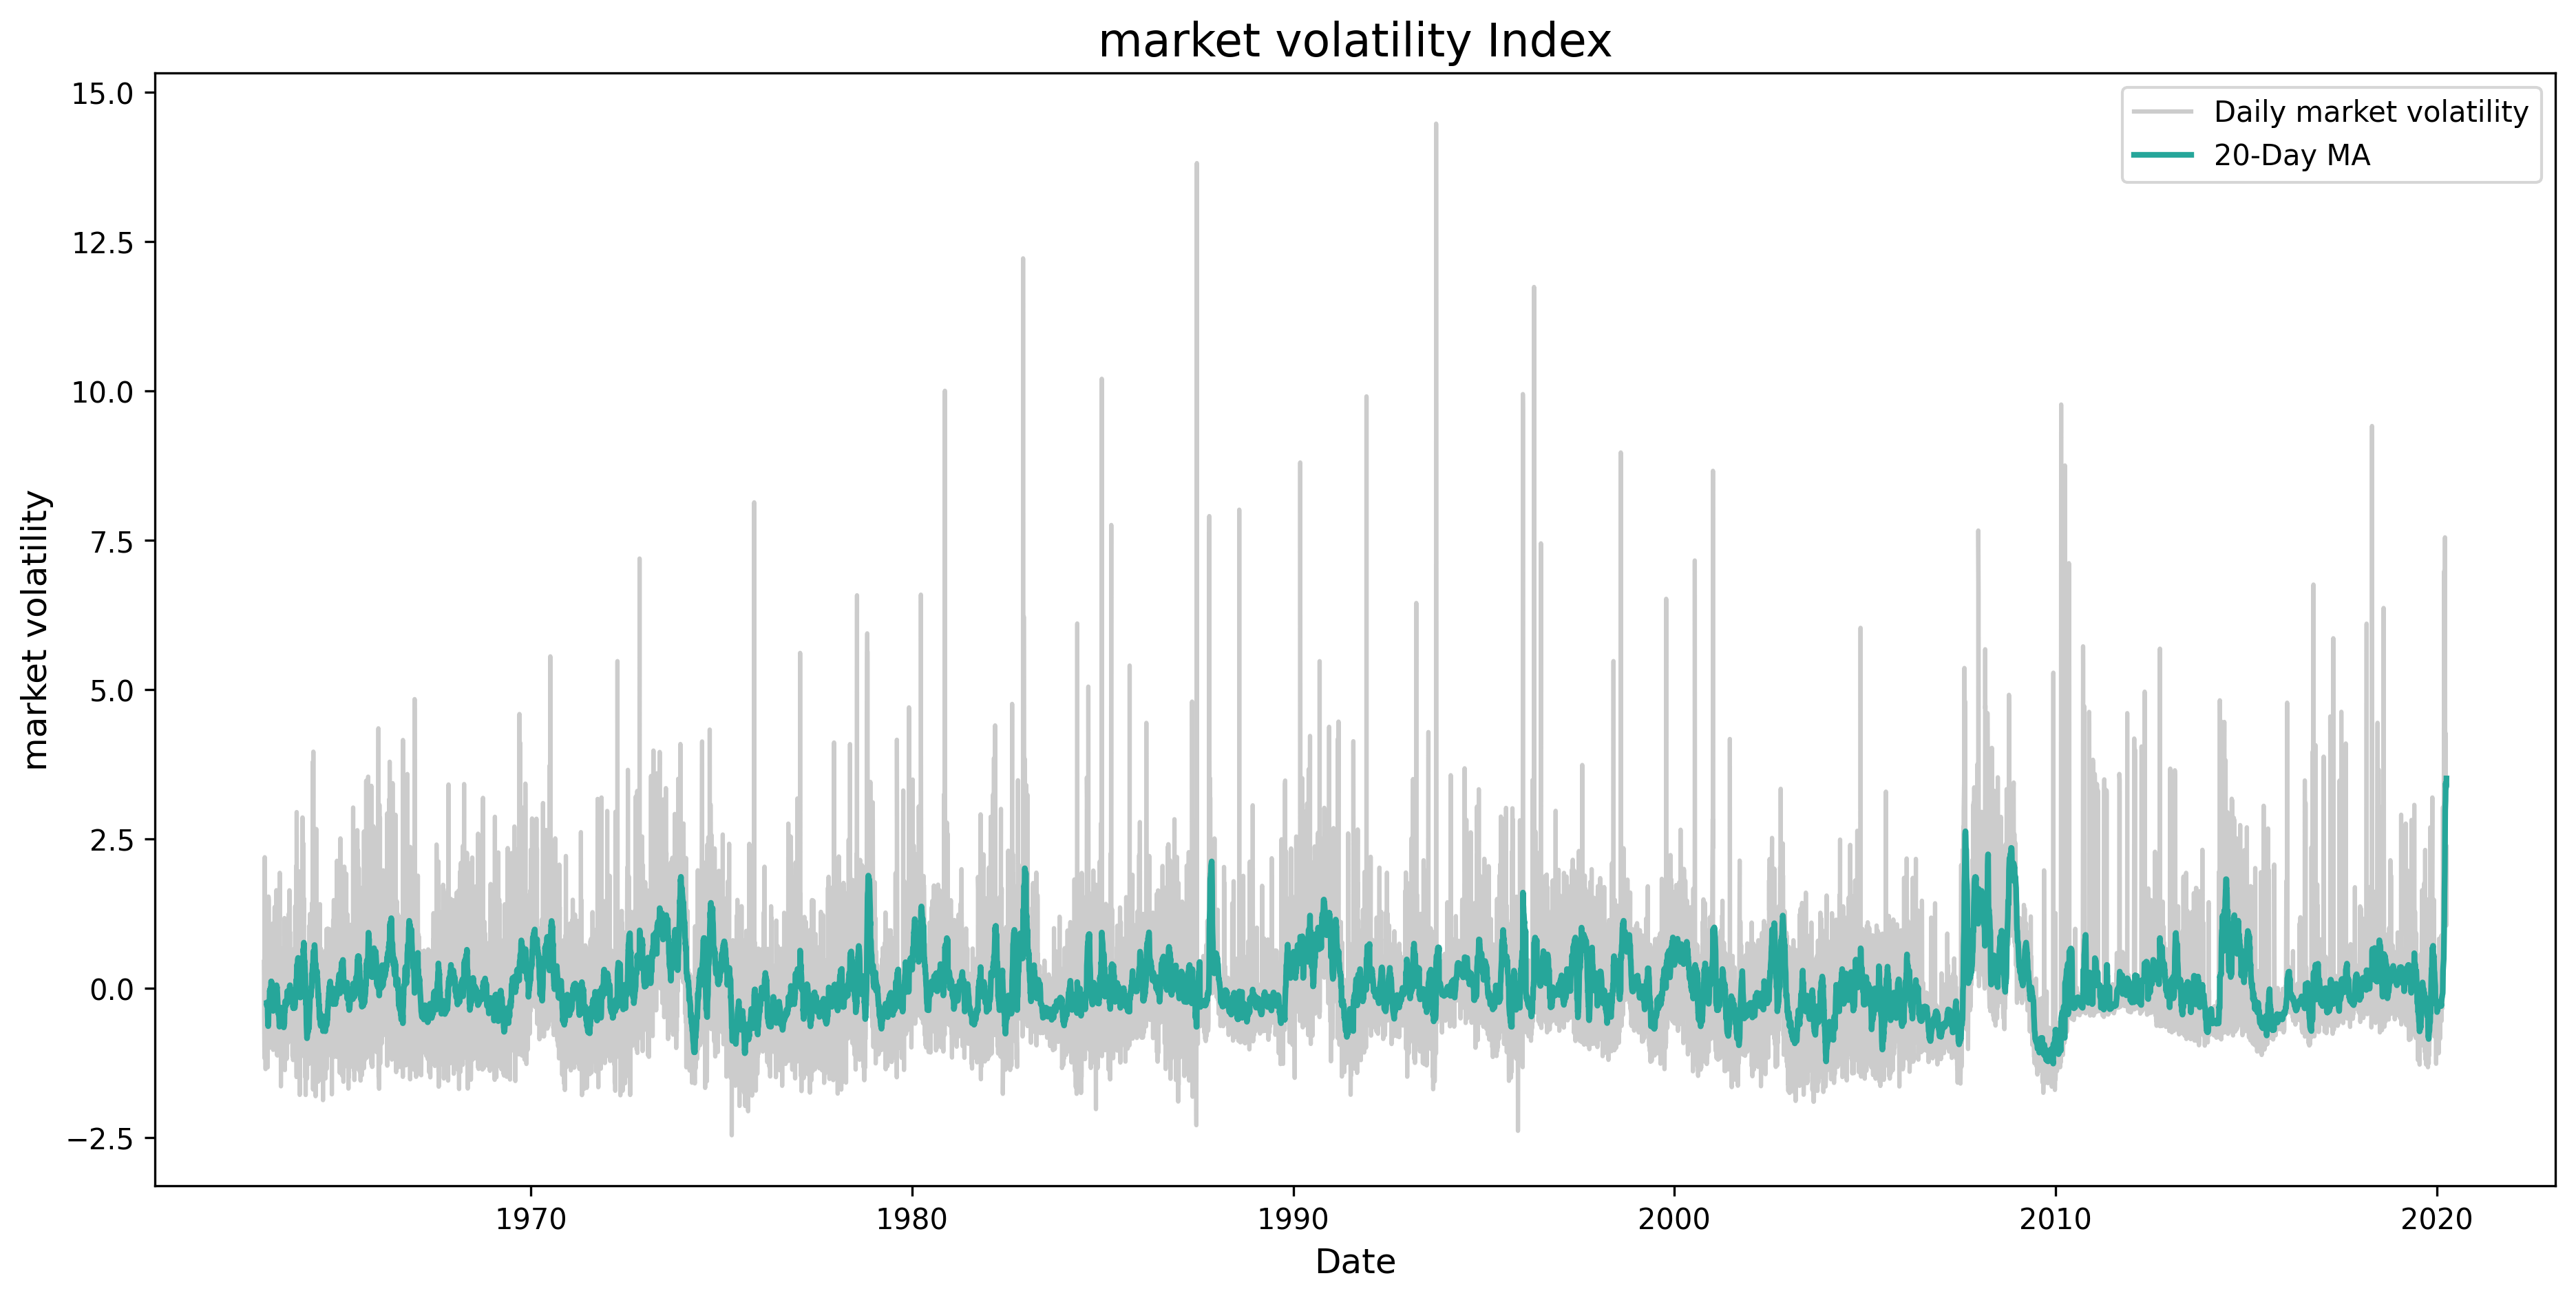

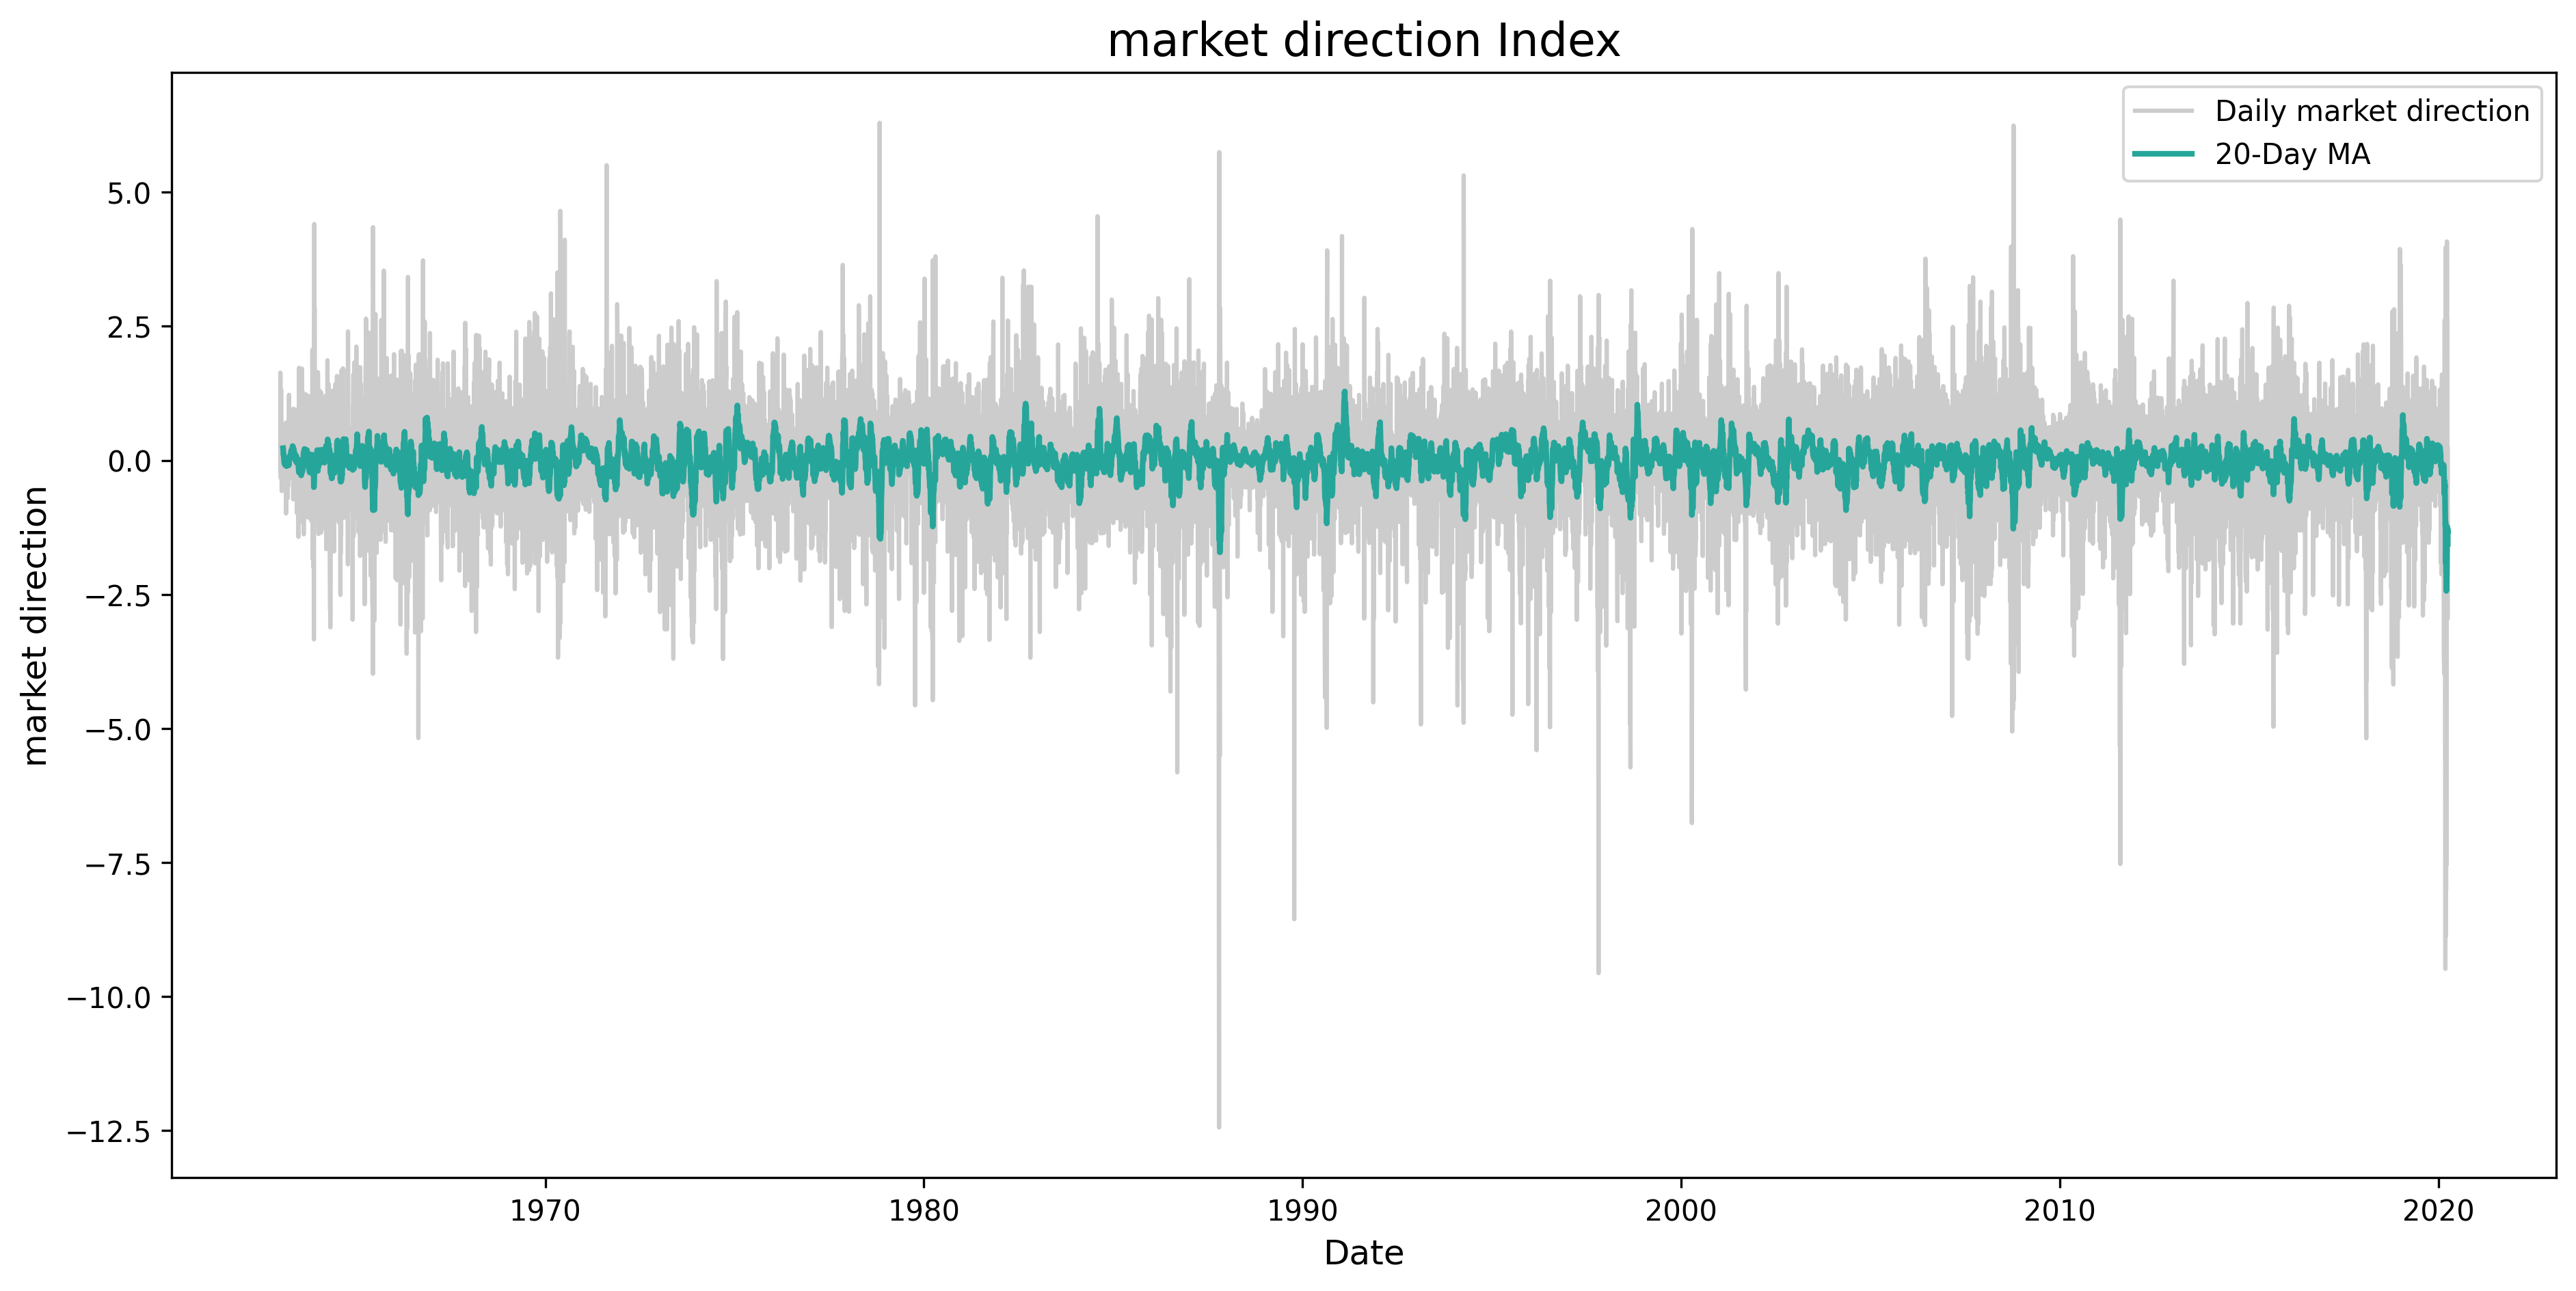

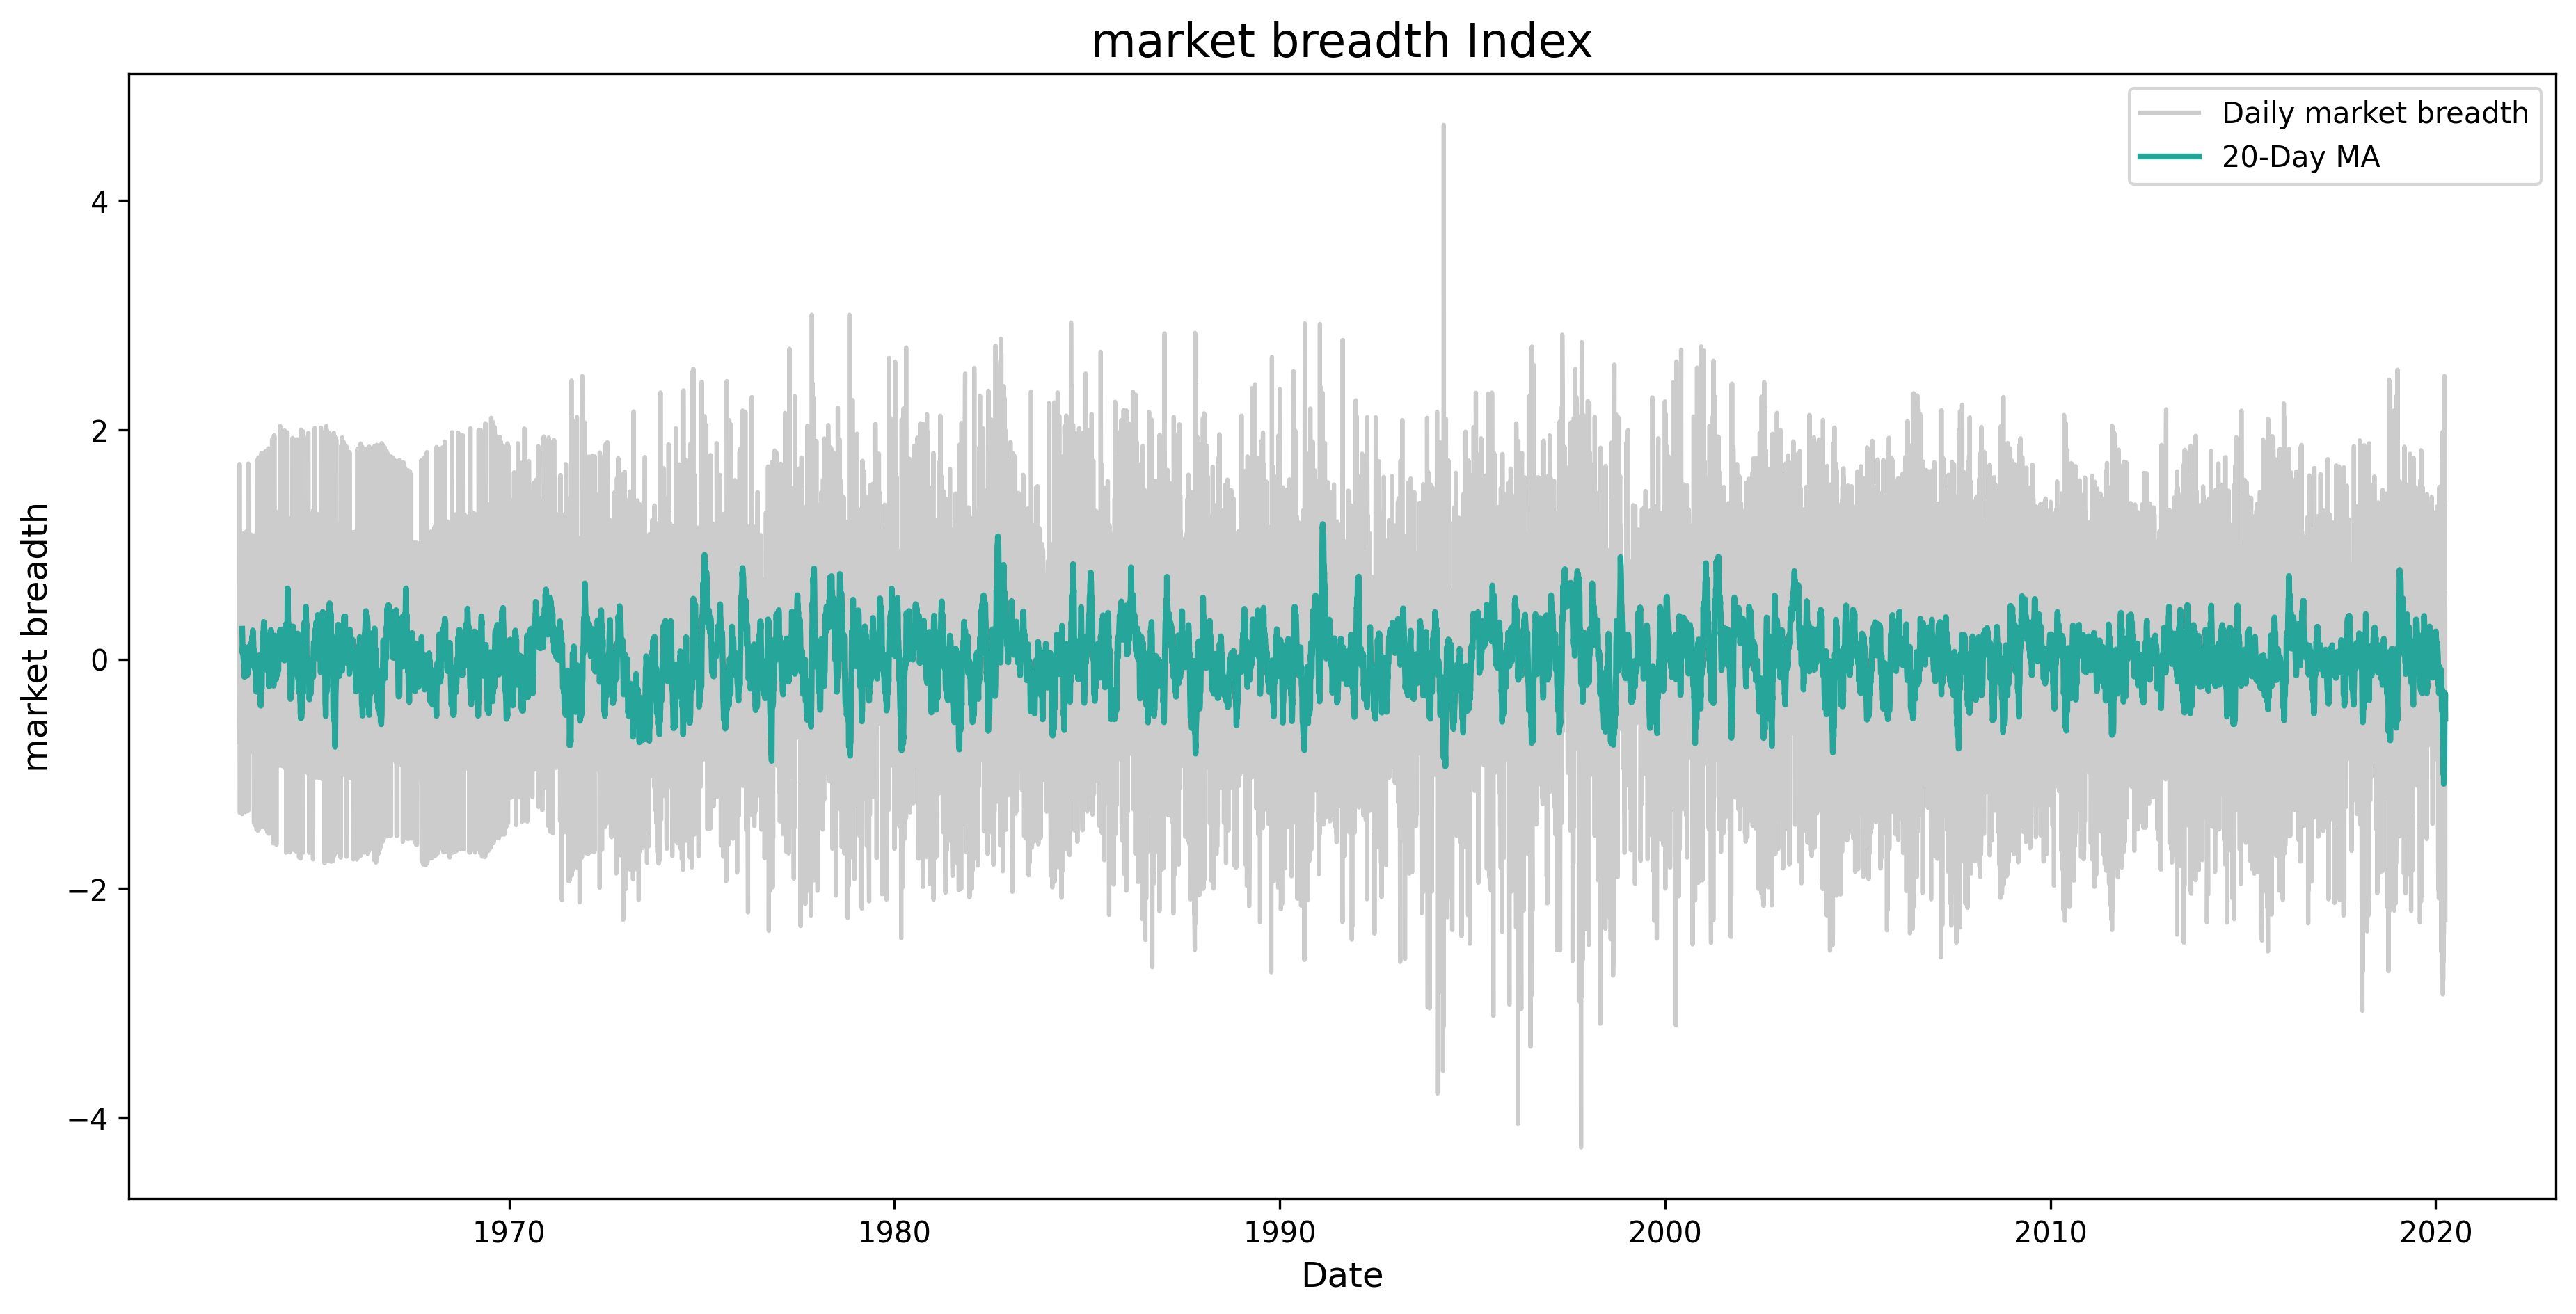

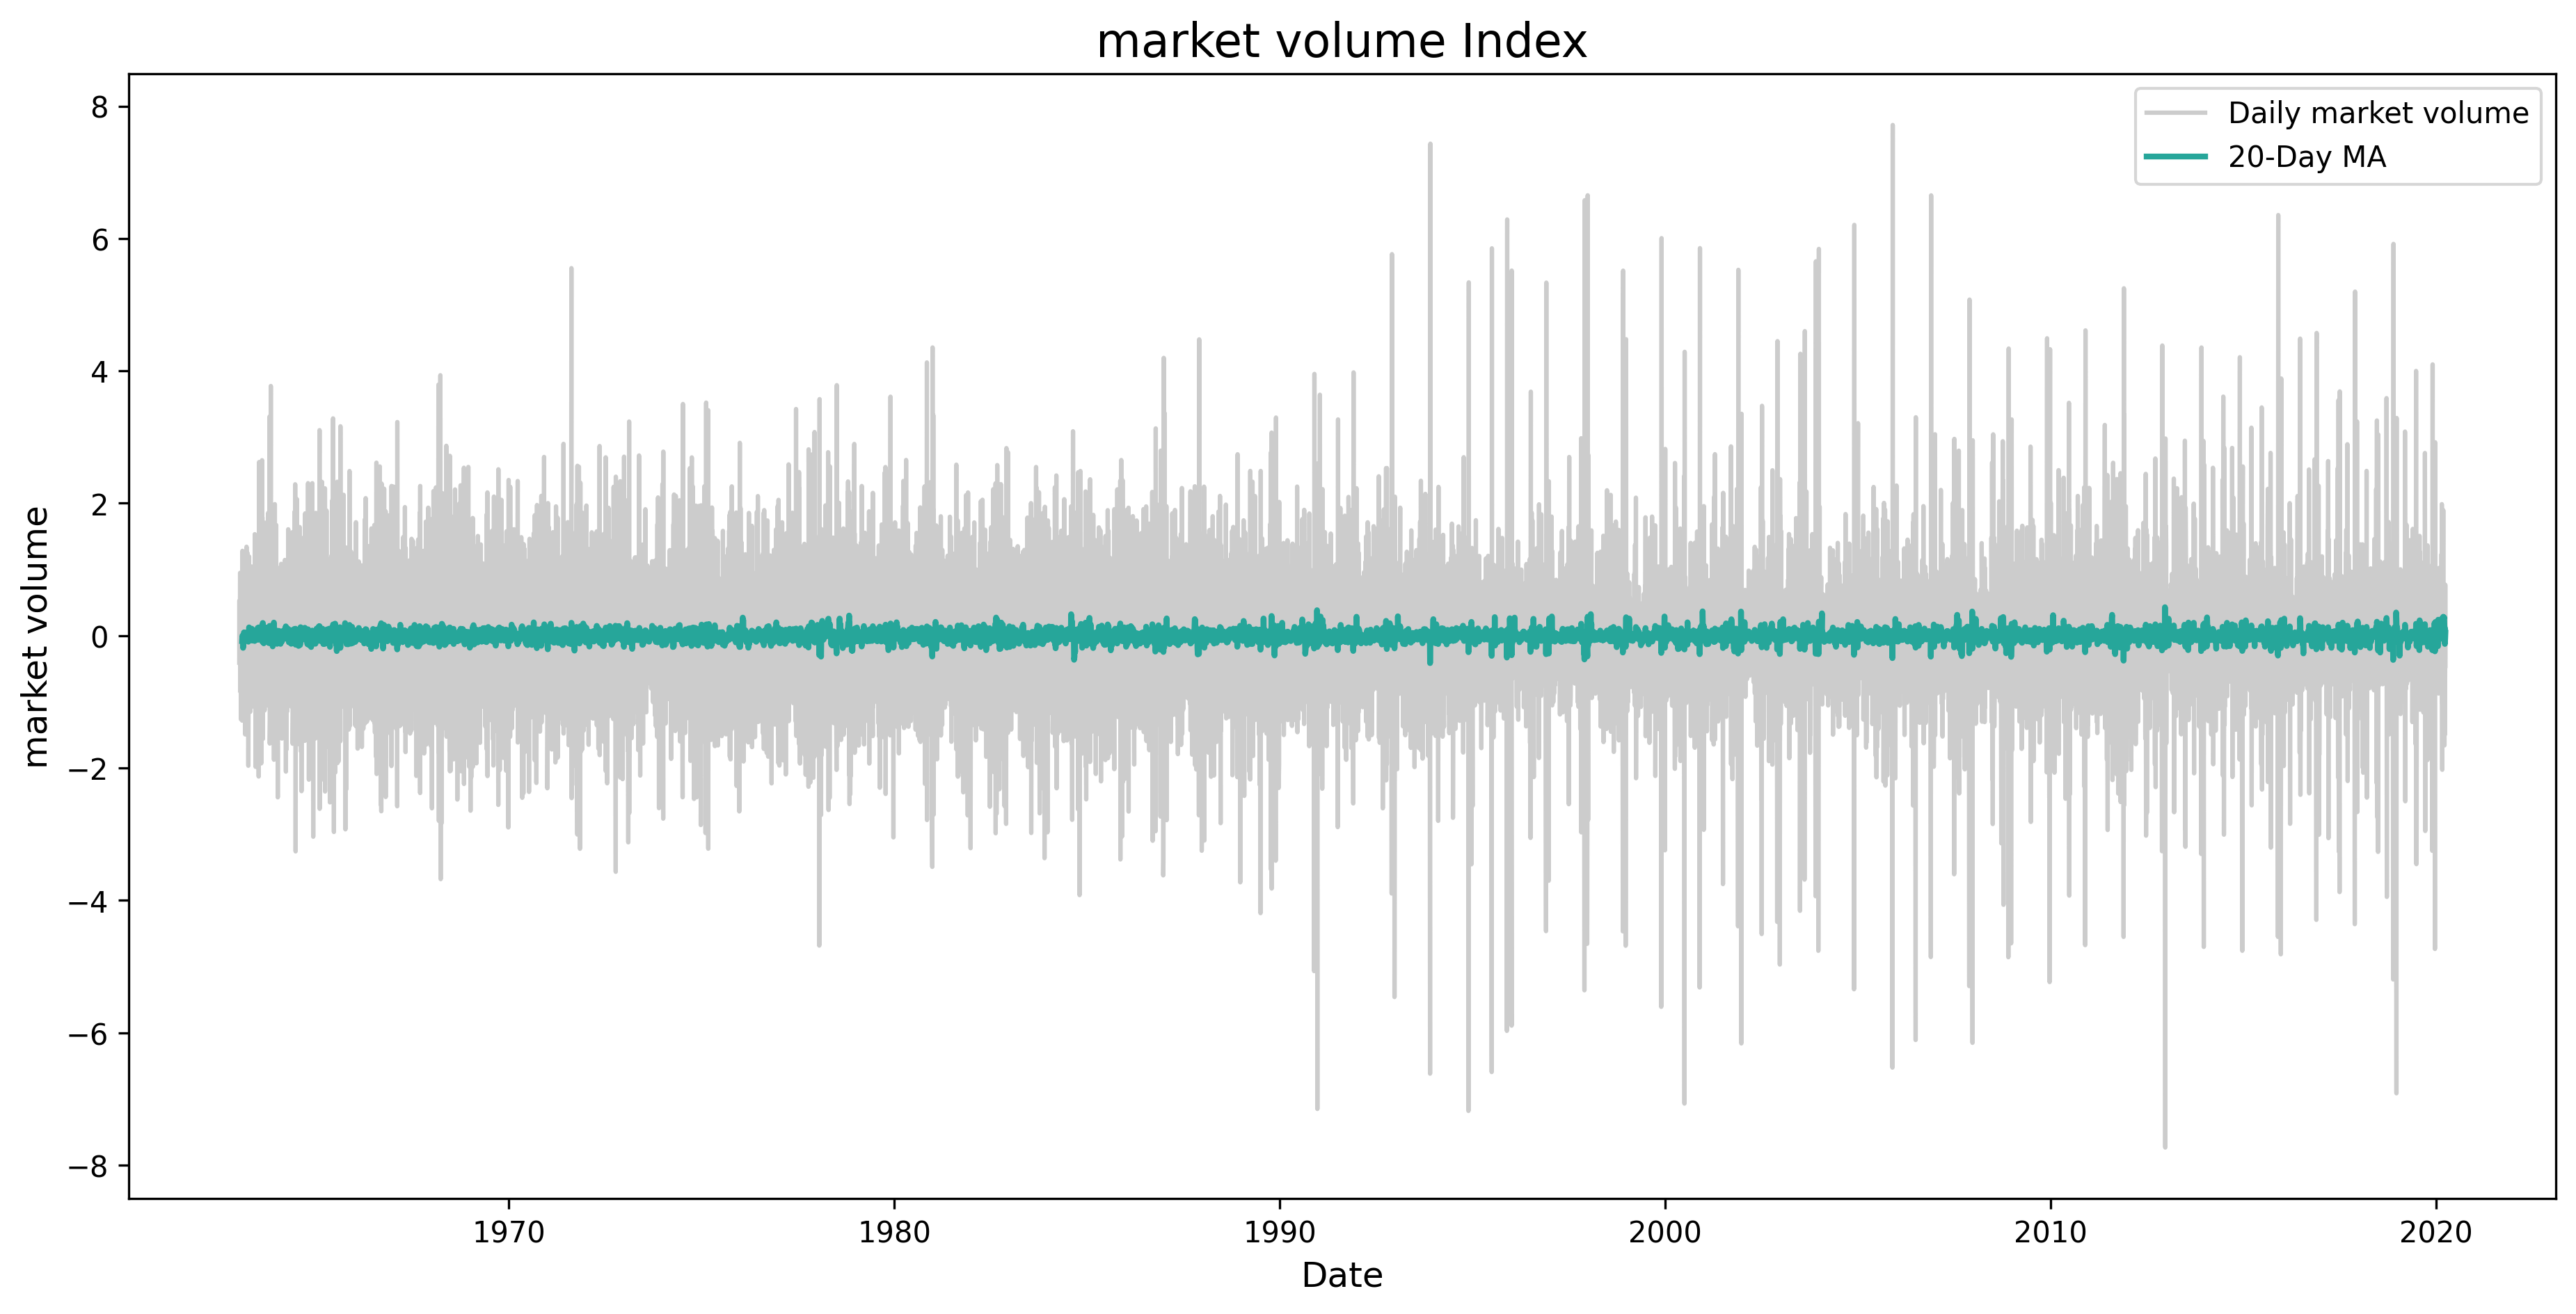

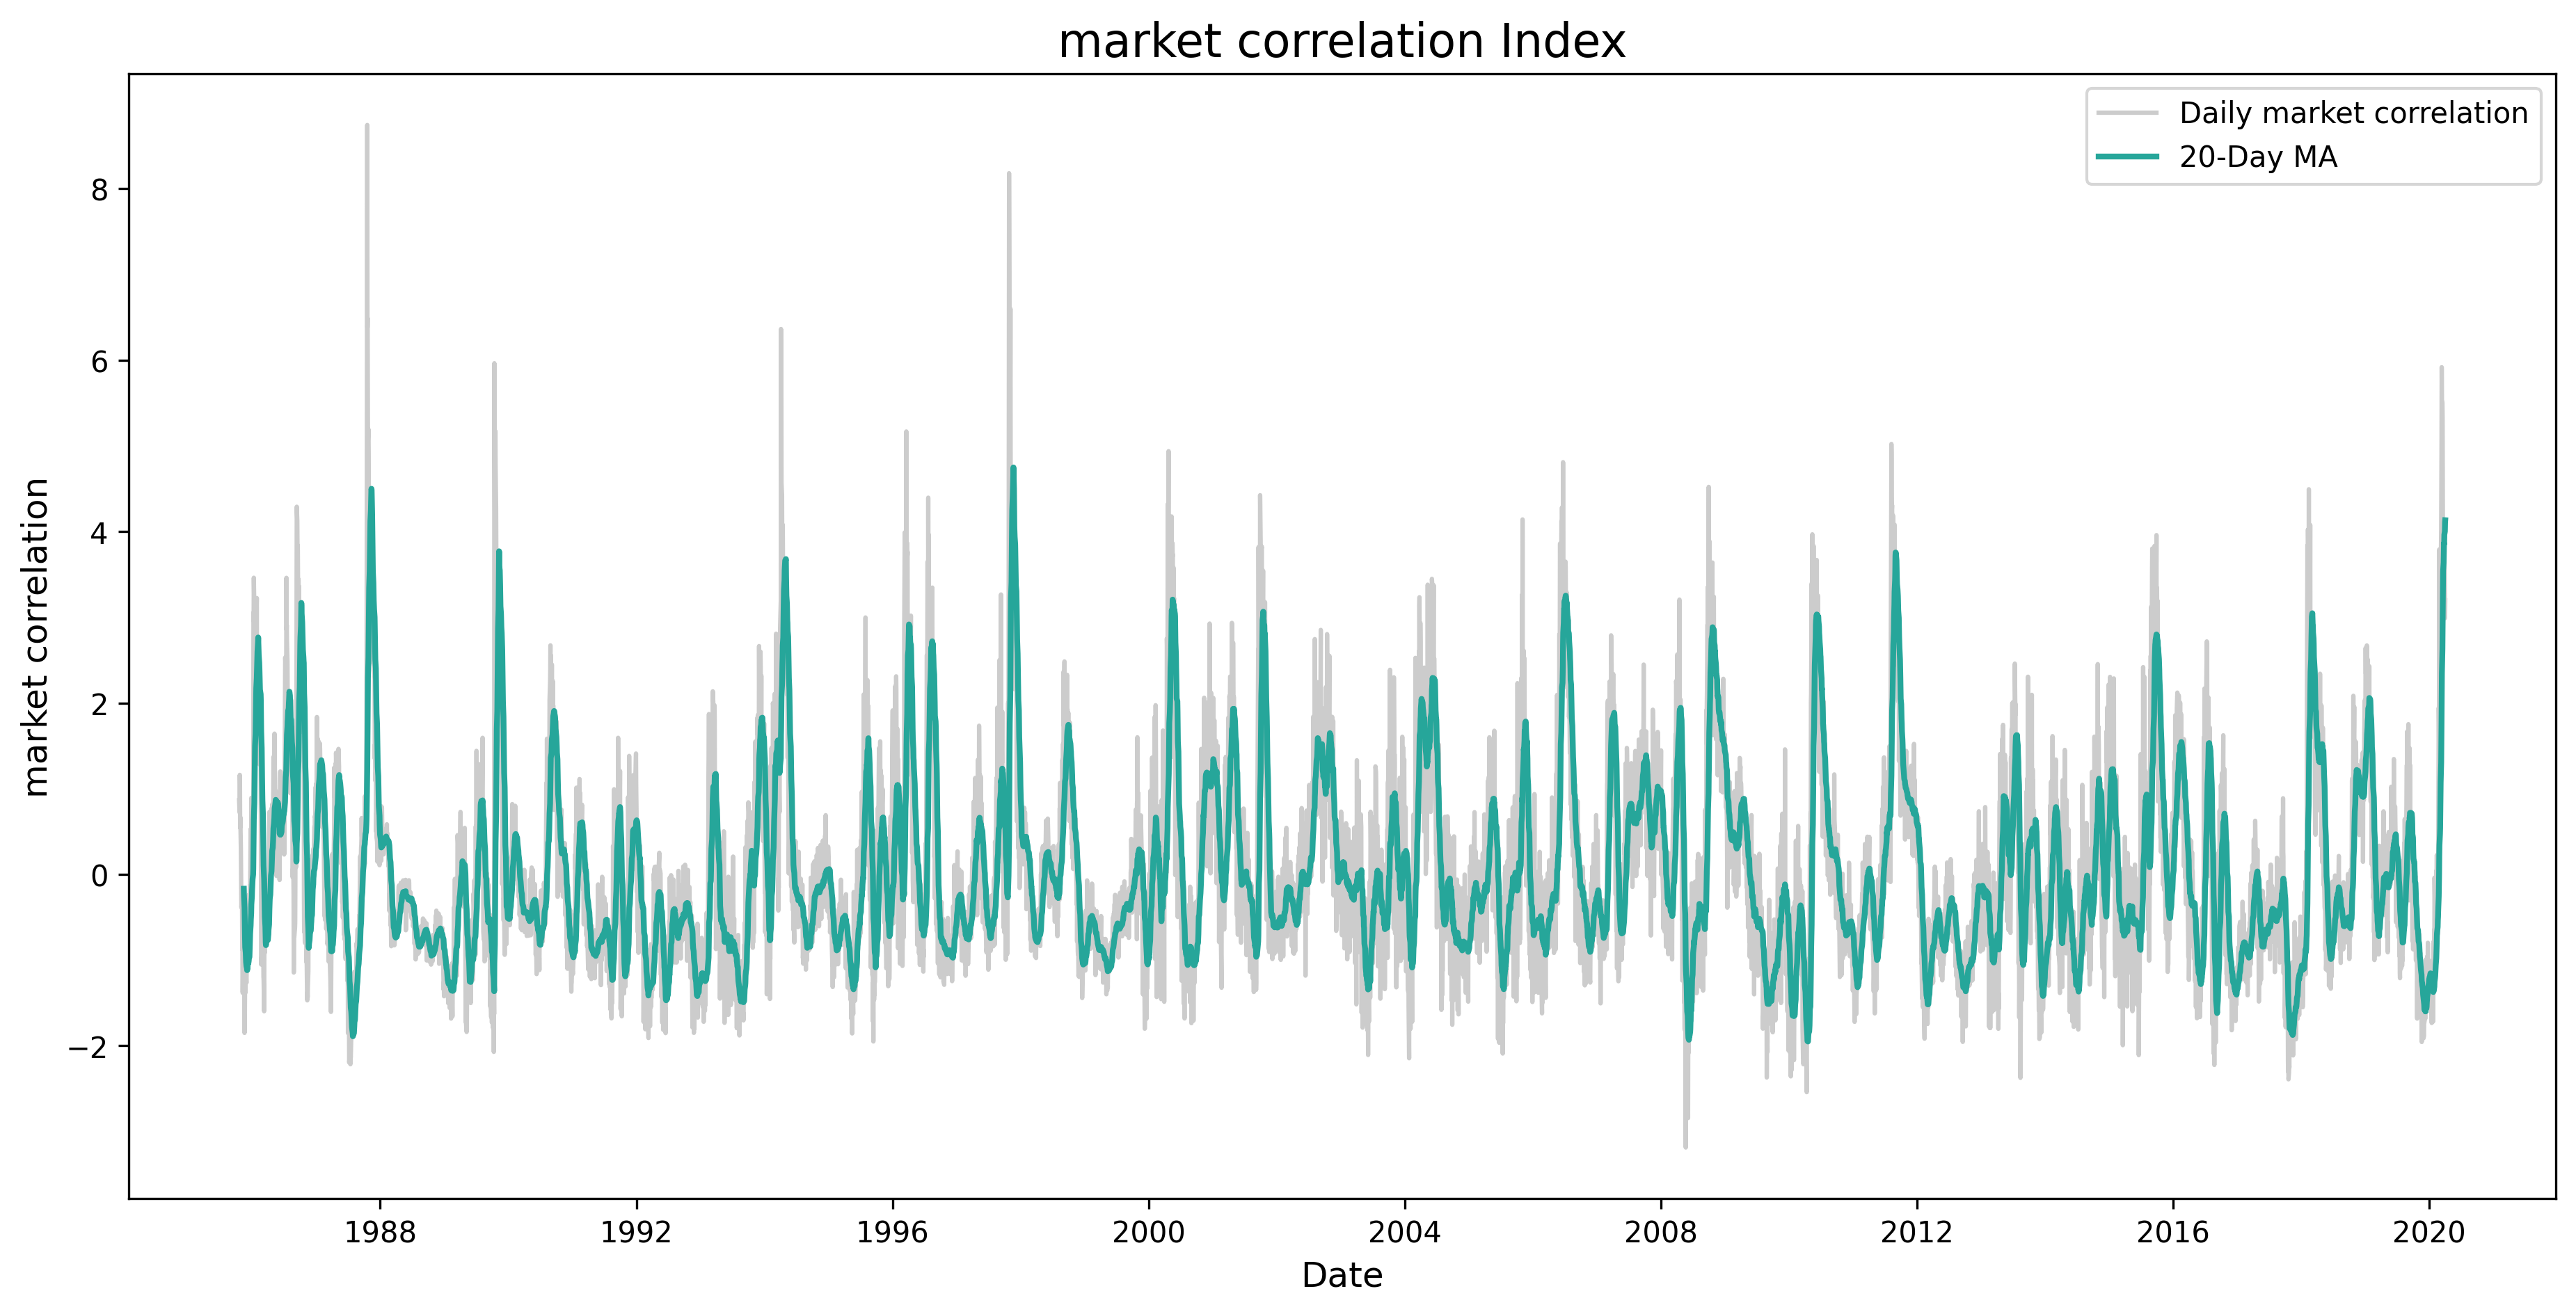

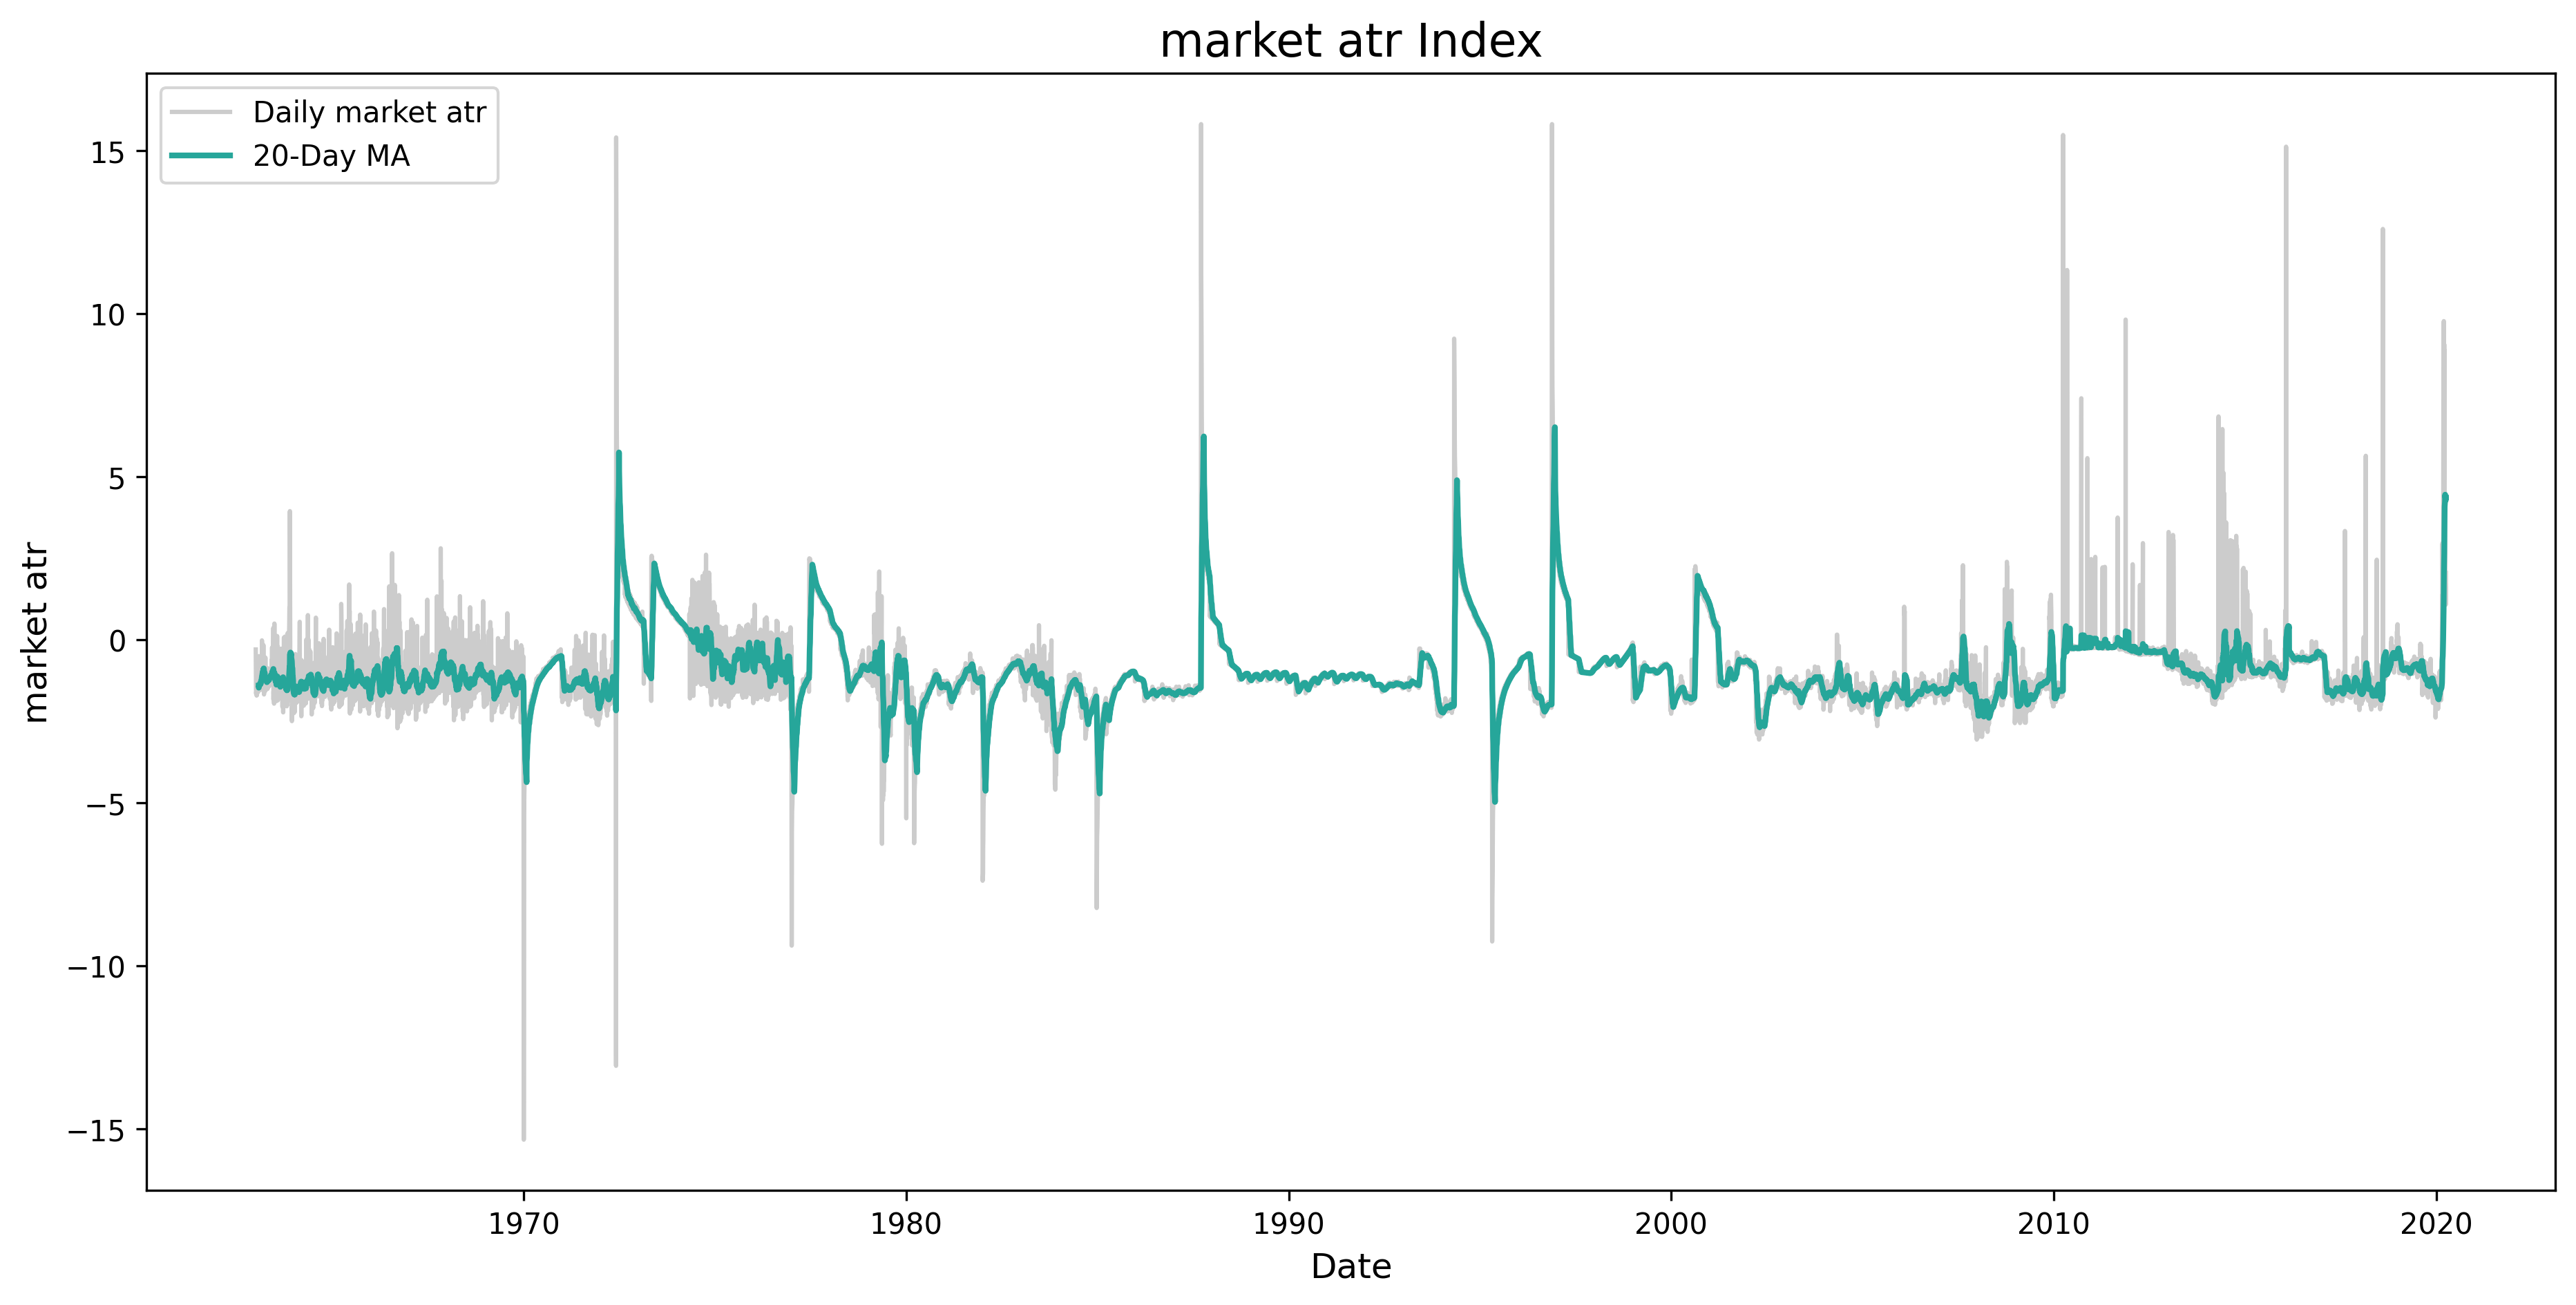

In [12]:
# Feature Standardization and Engineering for K-Means


# This structure serves as the input for the standardization function. Each key
# represents a feature that describes a specific facet of the market's state previously calculated
indicators_dict = {
    "market_direction": direction_df,
    "market_volume": volume_df,
    "market_volatility": volatility_df,
    "market_correlation": correlation_df,  
    "market_breadth": breadth_df,
    "market_atr": atr_df
}

# Standardize all indicators using a rolling Z-score.
# This transformation is critical for K-Means. It rescales each indicator to have a
# mean of ~0 and a standard deviation of ~1, ensuring that each feature contributes
# equally to the distance calculations in the clustering algorithm. The result,
# 'moodindex', represents the daily "abnormality" of each indicator relative to its history.
# The rolling window was chosen to be 252 days, a year of trading days.
moodindex = compute_mood_index(indicators_dict, window=252)

# Visual Analysis of Standardized Indicators
plot_market(moodindex, "market_volatility",[20])
plot_market(moodindex, "market_direction",[20])
plot_market(moodindex, "market_breadth",[20])
plot_market(moodindex, "market_volume",[20])
plot_market(moodindex, "market_correlation",[20])
plot_market(moodindex, "market_atr",[20])

The best performing indicators are volatility, correlation, and ATR as they provide the clearest and most interpretable signals over time. When plotted as time series, these three metrics display distinct trends and fluctuations that align well with market movements, making them easier to read visually. In particular, we can see that they show disctinctive spike for crisis event, such as the 1987 black monday, the dot com bubble, the 2008 subprime crisis, and the covid crisis, to name only a few example. They also capture complementary aspects of market behavior: volatility reflects price dispersion, correlation shows co-movement between assets, and ATR measures the degree of price variation.  

Indicators such as the market volume or market direction show at first glance weaker pattern correlation with crisis event, and are thus discarded for the prelimanary K-means analysis. However, these features are retained for future analysis, as they may hold synergistic value when combined with other variables in more complex models. They will be re-evaluated post-clustering. 

As a note, looking at the graph, it seems that the previously selected 20 days window moving average allows us to get smoother curves and gets rid of some noise in these indicators. For the K-means model, we will first start with the raw data, but we will experiment with moving average to see if and how it can improve the K-means algorithm.


## 8. Create market divergence feature

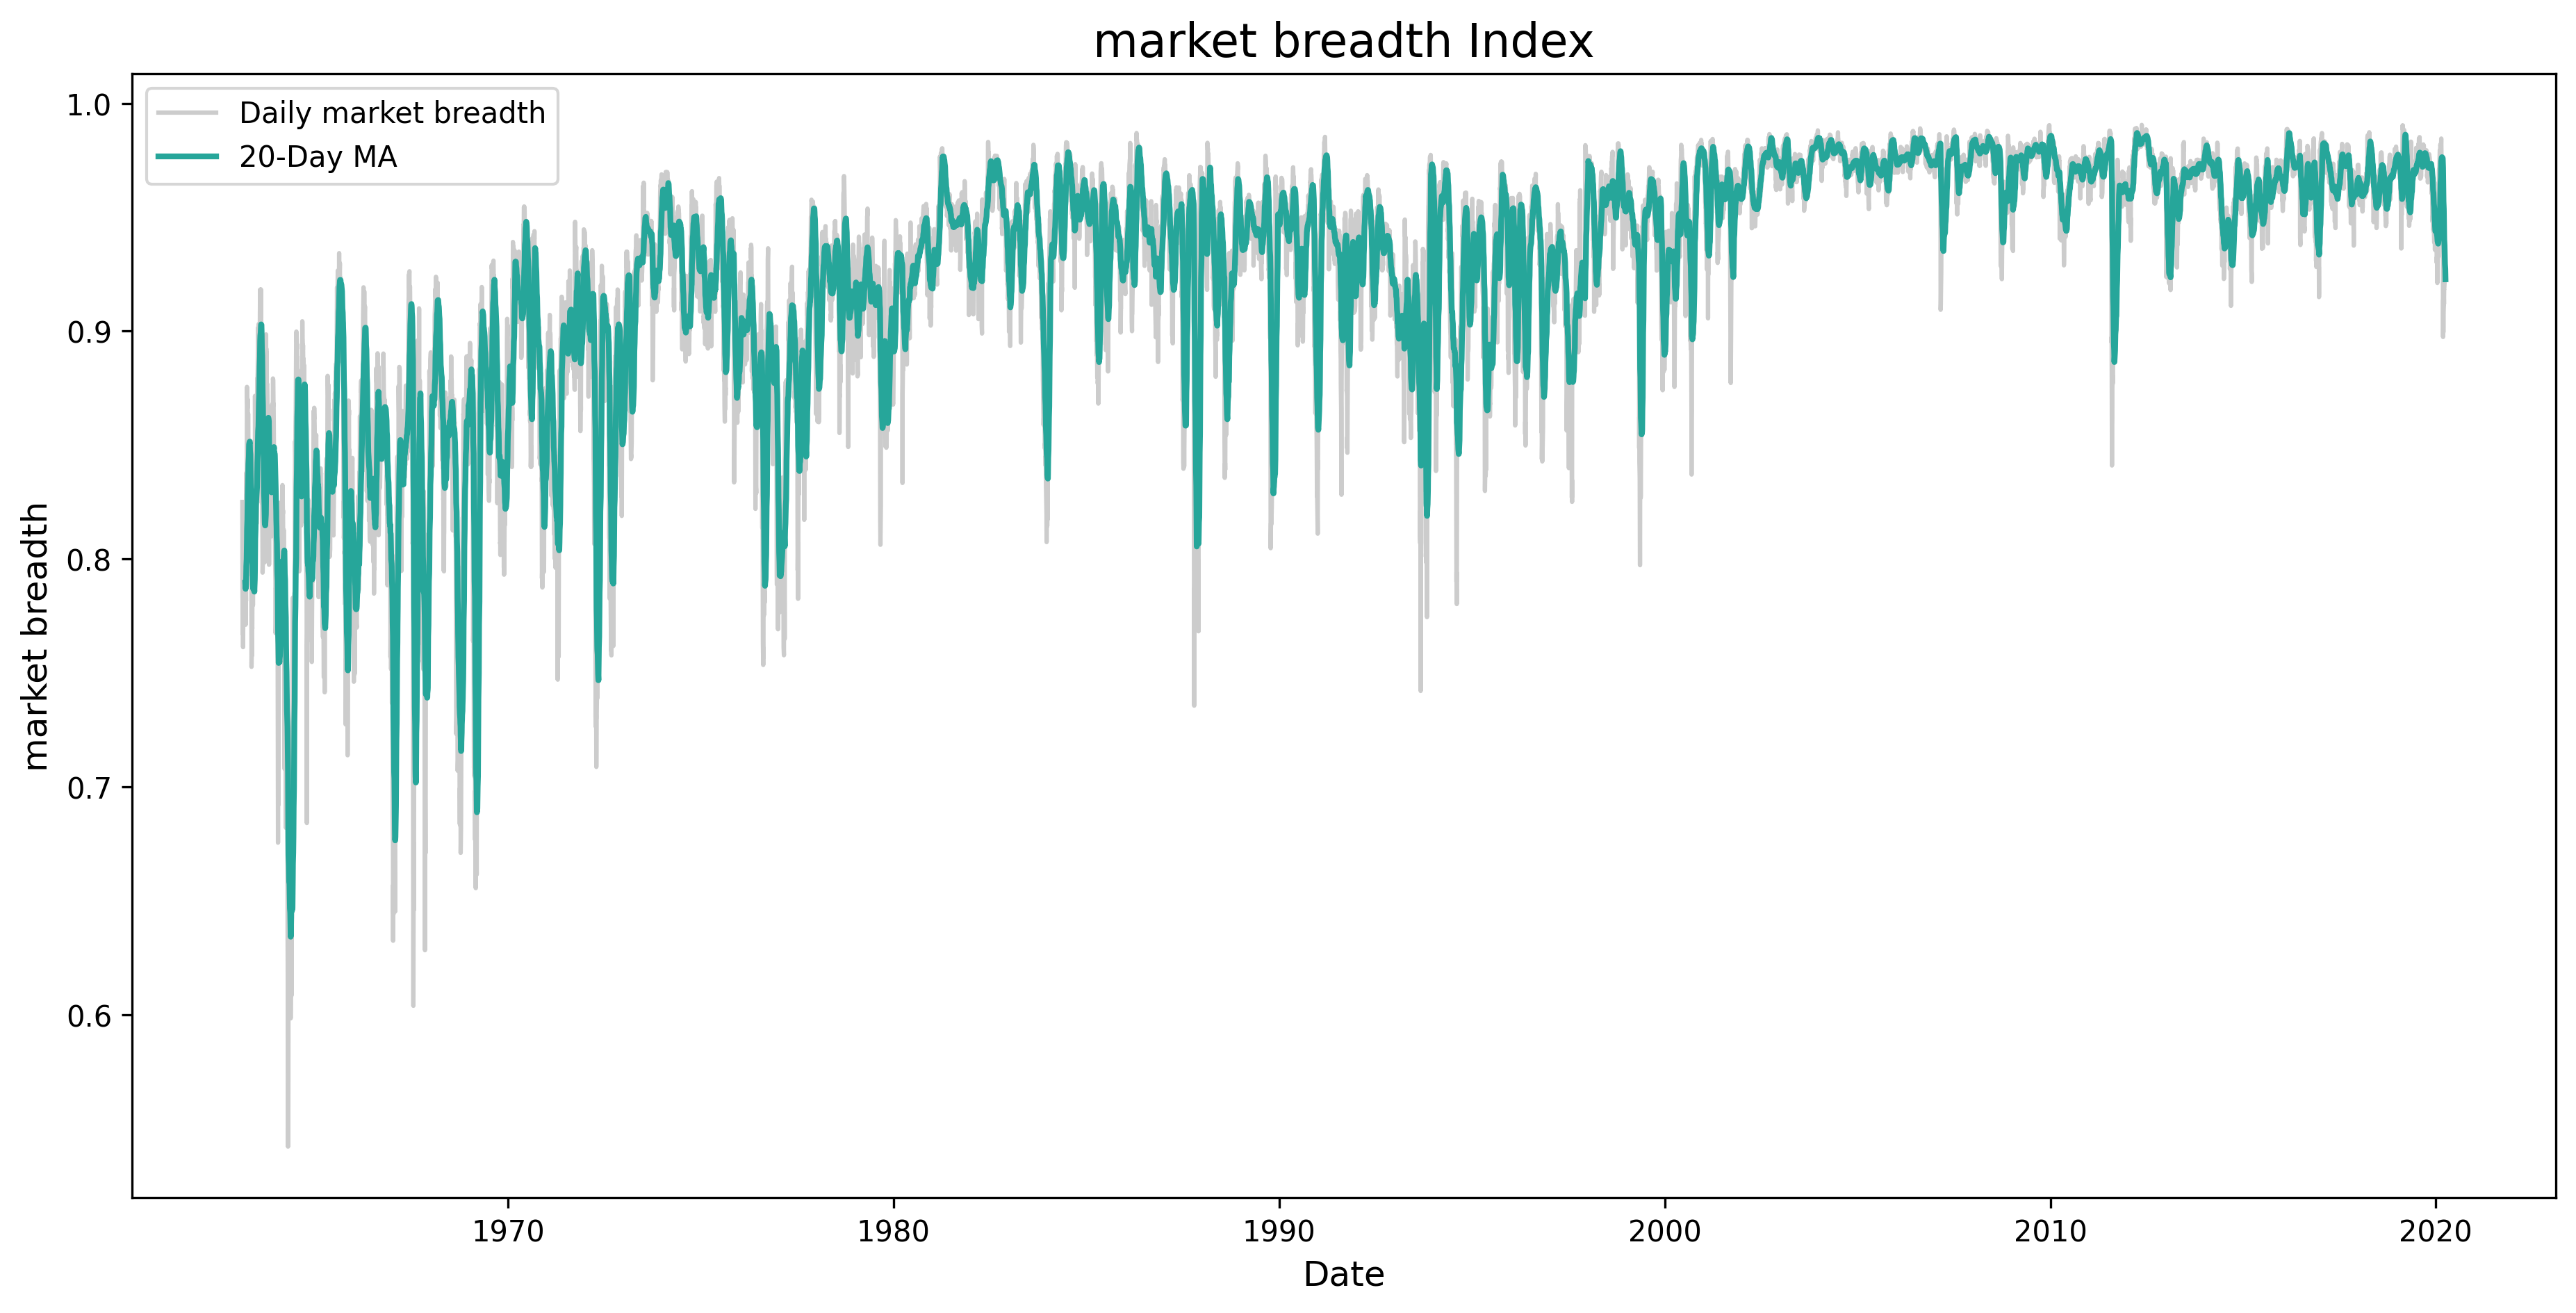

In [13]:
# The correlation between the index_market direction and market_breadth is computed
rolling_corrs = compute_rolling_corr(moodindex, "market_direction", 30)
plot_market(rolling_corrs,"market_breadth",[20])

From the plot above, we can see that 'market_direction' (mean return) and 'market_breadth' (% of rising stocks) are highly correlated (above 0.6 all the time). To avoid feeding redundant information into the model and to capture the information in their difference, we create a new feature.

In [14]:
# A high divergence indicates that a few large-cap stocks are driving the market's
# average return, a potential sign of a fragile trend.
moodindex['market_divergence'] = moodindex['market_direction'] - moodindex['market_breadth']

### 9. Feature selection for K-mean
In this section, the selection of relevant features is made. This is an important step to ensure that the K-means clustering captures meaningful patterns in market behavior.  
To ensure we select the right indicator and give them the right weight, we use Principle Component Analysis. This aproach presents two main advantages:
* Manages correlation between indicators : The financial indicators we computed in the previous section are generally highly correlated, we verified this when computing the correlation between the market correlation index and the market breadth index. PCA mathematically resolves this by compressing correlated components into orthogonal components.
* extracts hidden variable : We hypothesize that the stress indicator for the market is hidden, we can not compute it or measure it directly from the data, but it manifests throught related indicators, such as high volatility, wider ATR ranges and higher asset correlation. PCA effectively allows us to identify and isolate this indicator. 

Explained Variance Ratio: [0.29065305 0.2444379 ]


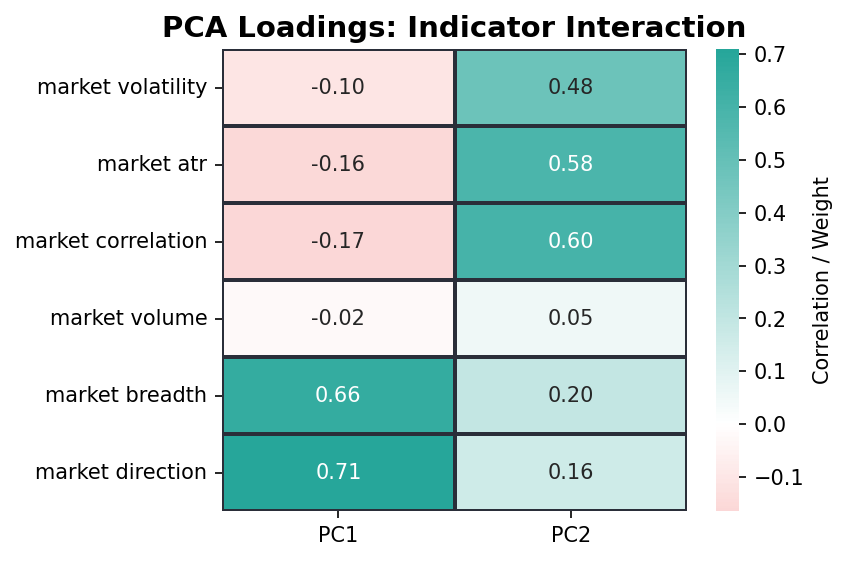

In [15]:
# Select ALL standardized mood indicators
feature_cols = [
    'market_volatility', 
    'market_atr', 
    'market_correlation', 
    'market_volume', 
    'market_breadth', 
    'market_direction'
]

X = moodindex[feature_cols].dropna()

# Apply PCA
# We look for the first 2 components. 
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

# Store results back in DataFrame
moodindex.loc[X.index, 'PC1'] = principal_components[:, 0]
moodindex.loc[X.index, 'PC2'] = principal_components[:, 1]

# Explained Variance: How much information did we keep?
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# Loadings: What actually IS PC1? 
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=feature_cols
)

# --- CLEANUP FOR DISPLAY ---
# Replace underscores with spaces in the index labels
loadings.index = loadings.index.str.replace('_', ' ')

colors = ["#ef5350", "#ffffff", "#26a69a"]
trading_cmap = LinearSegmentedColormap.from_list("trading_red_green", colors)

plt.figure(figsize=(5, 4), dpi=150)

# Plot the Heatmap
sns.heatmap(
    loadings, 
    annot=True, 
    cmap=trading_cmap,  # Use our custom Green/Red map
    center=0,           
    fmt=".2f",          
    linewidths=1,       
    linecolor='#2a2e39',
    cbar_kws={'label': 'Correlation / Weight'}
)

plt.title("PCA Loadings: Indicator Interaction", fontsize=14, fontweight='bold')
plt.show()

**PCA Analysis**  
By analyzing the PCA Loadings (the contribution of each feature to the component), we can identify two distinct market regimes:
* PC1: The "Trend/Health" Component, that explains 29% of the Variance
    * Heavily weighted by: Market Direction and Market Breadth.
    * This component captures the directional momentum of the market (Bull vs. Bear). It tells us where the market is going, but not necessarily how fragile it is.
* PC2: The "Systemic Stress" Component, that explains 24.5% if the Variance
    * Heavily weighted by: Volatility, ATR, and Correlation. These were the indicators we previously said were related to market stress.
    * This component captures Panic.
    * Crucially, PCA shows that these three variables move together to define stress. A high PC2 score represents a market that is volatile (Vol), gapping intraday (ATR), and moving in lockstep (Correlation).
      
**Take-away:**

We selected PC2 as our primary "Mood Index" because it isolates structural fragility from simple price direction.

In [16]:
# Use the index from X (the data used for PCA) to align the rows correctly
moodindex.loc[X.index, 'market_trend_pc1'] = principal_components[:, 0]
moodindex.loc[X.index, 'systemic_stress_pc2'] = principal_components[:, 1]

In [17]:
model_package = {
    'pca_model': pca,              # The fitted sklearn PCA object
    'feature_cols': feature_cols   # The list ['market_volatility', 'market_atr', etc.]
}

## First visual confirmation  
We can plot this compound indicator and compare it again major event crisis, and verify if it aligns correctly with these stress events.

In [18]:
# We create a dictionnary of major crisis for the plot
events_complete = {
    "Russian Crisis & LTCM": ("1998-08-01", "1998-11-01"),
    "Black Monday": ("1987-09-01", "1987-12-31"),
    "Asian Financial Crisis": ("1997-07-01", "1998-01-01"),
    "Dot-com Bubble Burst": ("2000-03-01", "2002-10-01"),
    "2008 Financial Crisis": ("2008-09-01", "2009-03-31"),
    "2011 Eurozone Crisis": ("2011-05-01", "2012-01-01"),
    "COVID-19 Crash": ("2020-01-15", "2020-04-01"),
    "1990 Recession": ("1990-07-01", "1991-03-01"), 
    "2015-16 Chinese Stock Crash / Oil Crash": ("2015-08-01", "2016-02-01"),
    "2018 Powell Pivot / Trade War": ("2018-10-01", "2018-12-31"),
    "1994 Bond Market Massacre": ("1994-02-04", "1994-11-15")
}

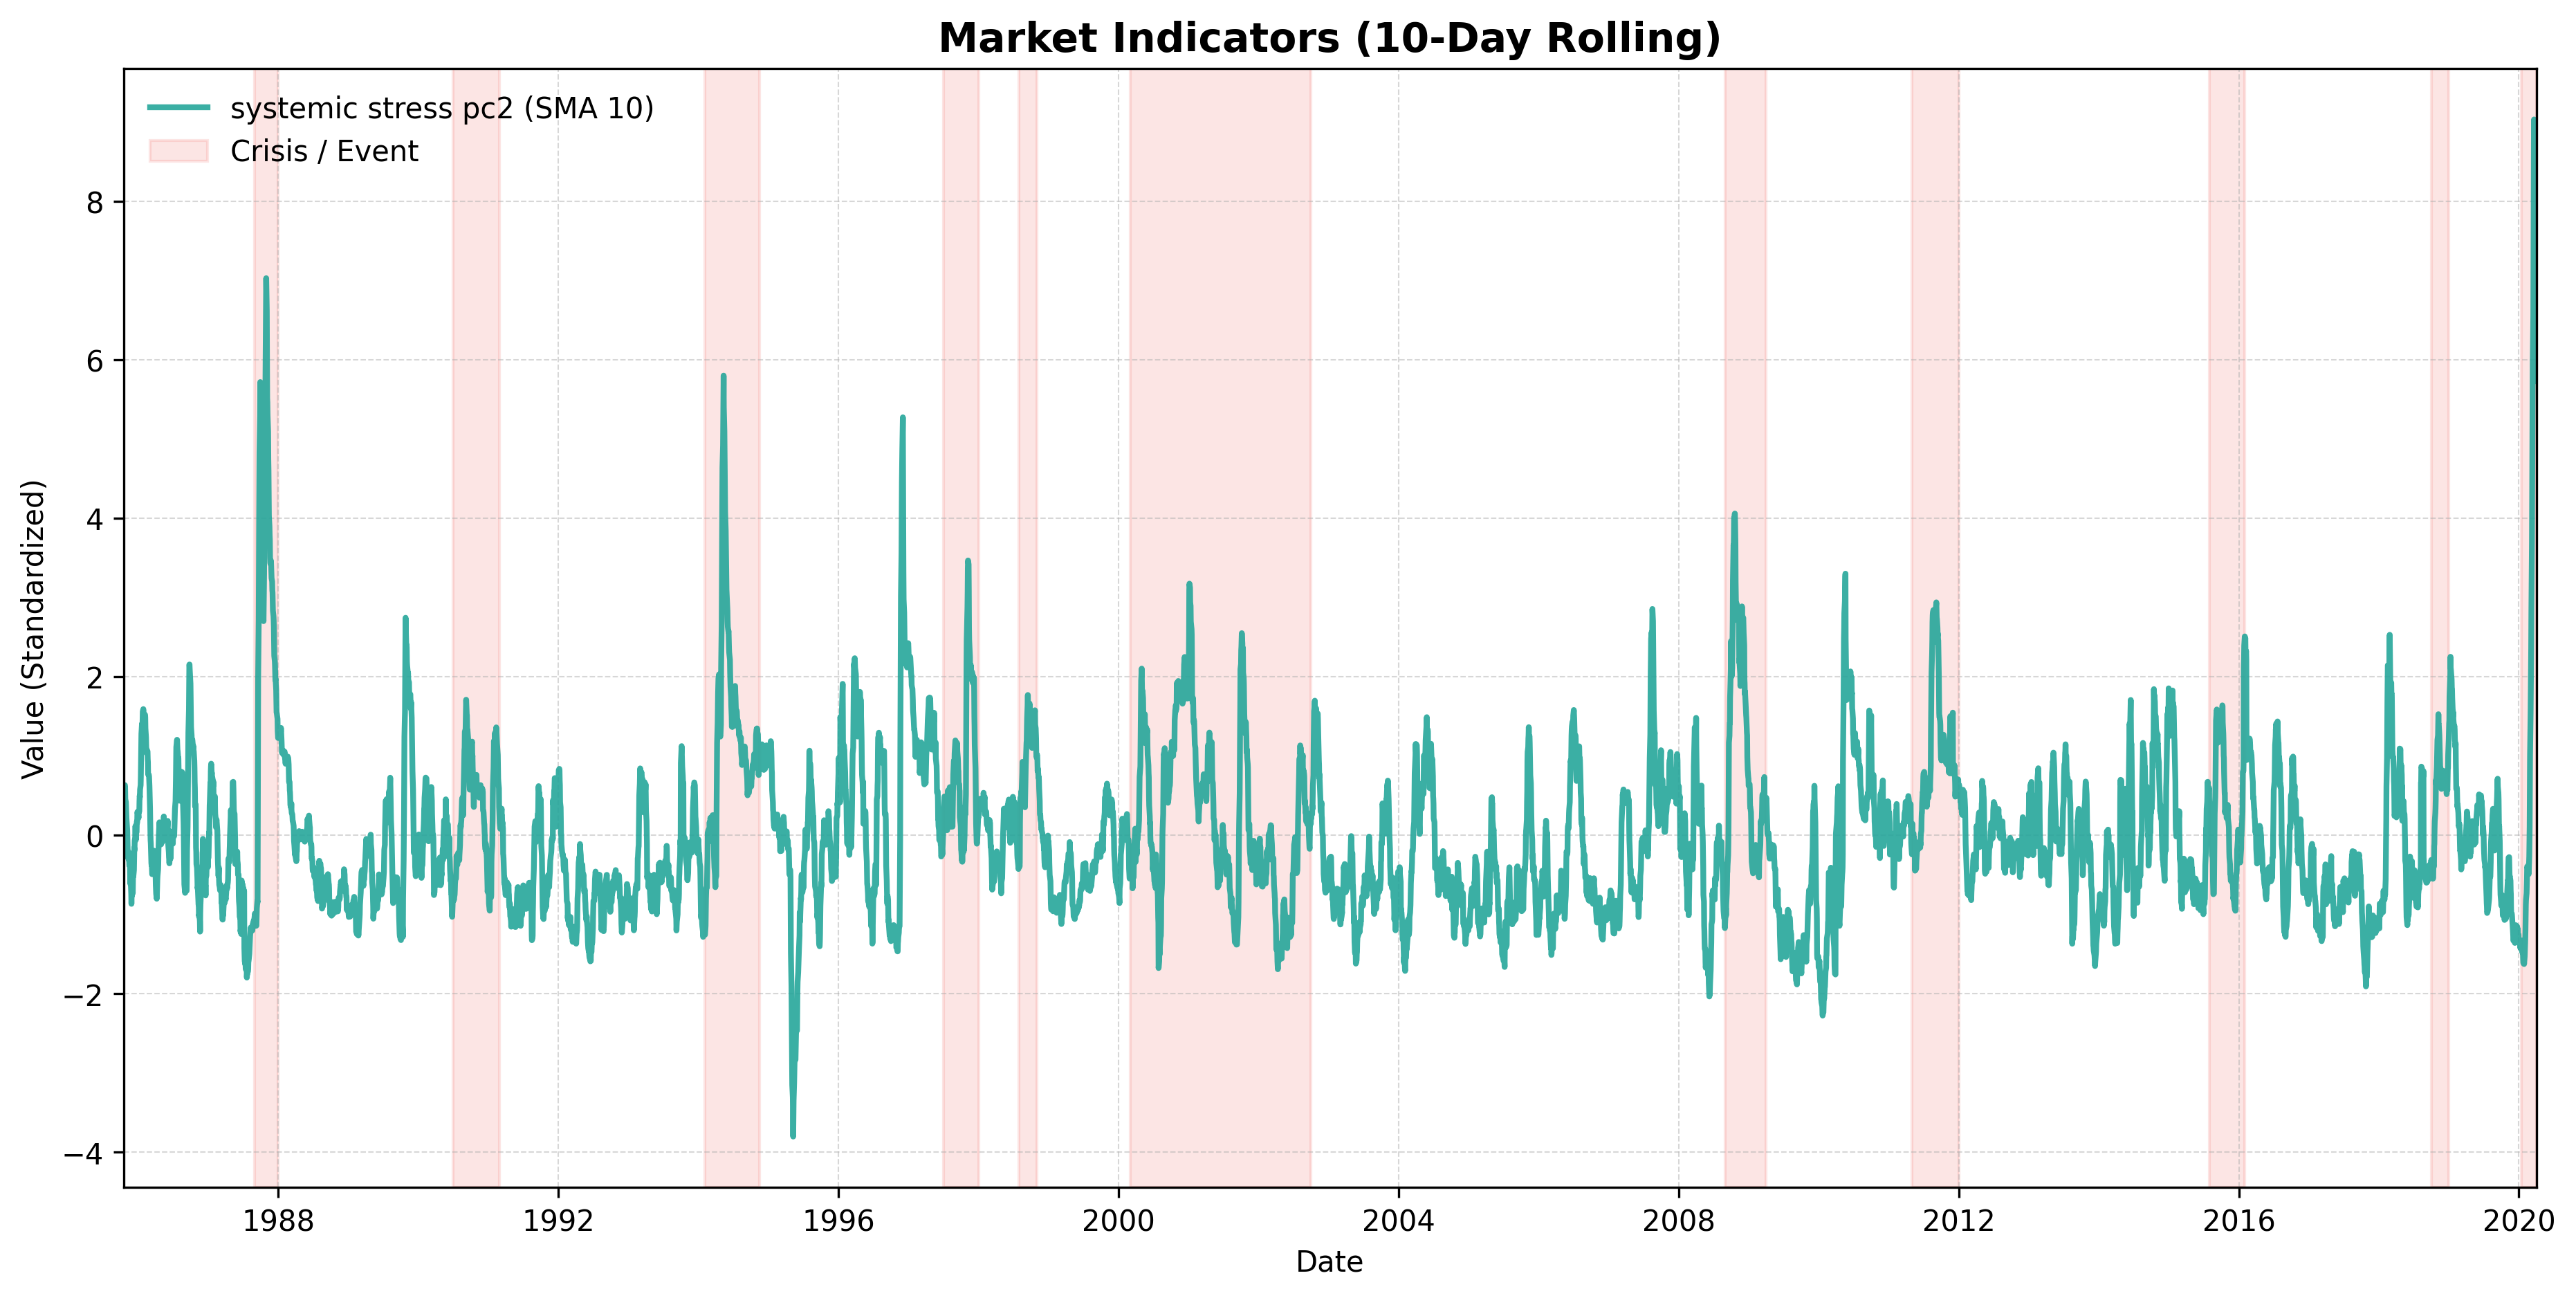

In [19]:
valid_start_date = moodindex['systemic_stress_pc2'].first_valid_index()
plot_data_1 = moodindex.loc[valid_start_date:].copy()

# Plot using the cleaned data
plot_rolling_with_events(
    plot_data_1, 
    events_complete, 
    ["systemic_stress_pc2"], 
    window=10 
)

This visual analysis confirms that the `systemic_stress_pc2` serves as a robust barometer for market crises.

**Key Strengths:**

*   **High Sensitivity to Major Shocks:** The indicator reacts unambiguously to the most significant financial crises. The sharpest peak in the dataset correctly aligns with Black Monday (1987), and the 2008 Subprime and 2020 COVID-19 crash are also marked by immediate and severe spikes.
*   **Captures Prolonged Stress:** The model effectively identifies not just sudden crashes but also extended periods of turmoil. During the Dot-com bubble (2000-2002), the indicator remains consistently elevated, reflecting the persistent nature of the crisis.
*   **Signal Stability:** During calm periods like the period between the end of the dot com bubble and the begining of the subprime crisis, the indicator correctly hovers near its baseline, indicating a low rate of false positives.

**Observations & Nuances:**
There seem to be some unexplicable spikes that do not match any of the events from our list of major crisis. Are these false positive wrongly identified by our indicator. Let's figure this out by comparing our stress indicator with the real state of the market.

# 10. Compute a Market Drawdown indicator 
To validate our Systemic Stress Index (PC2), we compare it against Market Drawdown. While volatility measures the speed of price changes, drawdown measures the magnitude of capital destruction. It serves as our primary approximation for the "State of the Market."  

*As a sidenote, We purposefully decided not to included drawdown in our PCA analysis to avoid lookahead bias. Drawdown is a lagging indicator (can only be computed after the crisis, as opposed to ATR or volatility that can be computed daily), and including it in our 'systemic_stress_pc2' would consistitute data leakage.*

**1. Mathematical Definition** 
Drawdown quantifies the percentage decline of an asset from its historical peak. It represents the loss an investor would experience if they had purchased the asset at the highest possible price prior to the current time be the price of the asset at time $t$.  
Let $P_t$ be the price of the asset at time $t$. First, we calculate the **Running Maximum** over the observed period $[0, t]$ :  
$$H_t=max(P_0,P_1,...,P_t)$$
The Drawdown at time $t$ $DD_t$ is computed as:
$$DD_t=\frac{P_t-H_t}{H_t}$$
Where:  
$DD_t=0$: The market is at an all-time high (Bull Market)  
$DD_t<0$: The market is in a decline. A value of -0.2 implies the market is 20% below its peak.  

We use **Drawdown** to categorize market regimes because it captures the psychological and structural reality of a crisis better than simple returns.
* **Asymmetry of Losses**: Drawdown highlights the "mathematical trap" of losses. A 50% drawdown requires a 100% subsequent gain to break even. Therefore, deep drawdowns indicate periods of extreme systemic stress.
* **Finance standard**: Financial industry standards define market states based on specific drawdown thresholds, which we utilize in our visualizations:
    * Correction: $DD_T$ ∈[−10%,−20%)
    * Bear Market: $DD_t \leq$ -20$
      
This Drawdown indicator will allow us to get a **Signal Validation**: by overlaying our PCA Stress Index against Drawdown, we can confirm if our index spikes specifically during periods of wealth destruction (True Positives) versus periods of harmless volatility.

In [20]:
# Calculate the cumulative max of the market (using Adj Close)
market_proxy = cleaned_df.groupby('Date')['Adj Close'].mean()

# Calculate Drawdown
rolling_max = market_proxy.rolling(window=252, min_periods=1).max()
daily_drawdown = (market_proxy / rolling_max) - 1.0

# Add to your moodindex for plotting
moodindex['market_drawdown'] = daily_drawdown

#Now that we have computed all relevant indicator, we can create the final extended feature dataframe
features_extended = moodindex.drop(columns=['PC1','PC2'])

## 11. Final visual confirmation

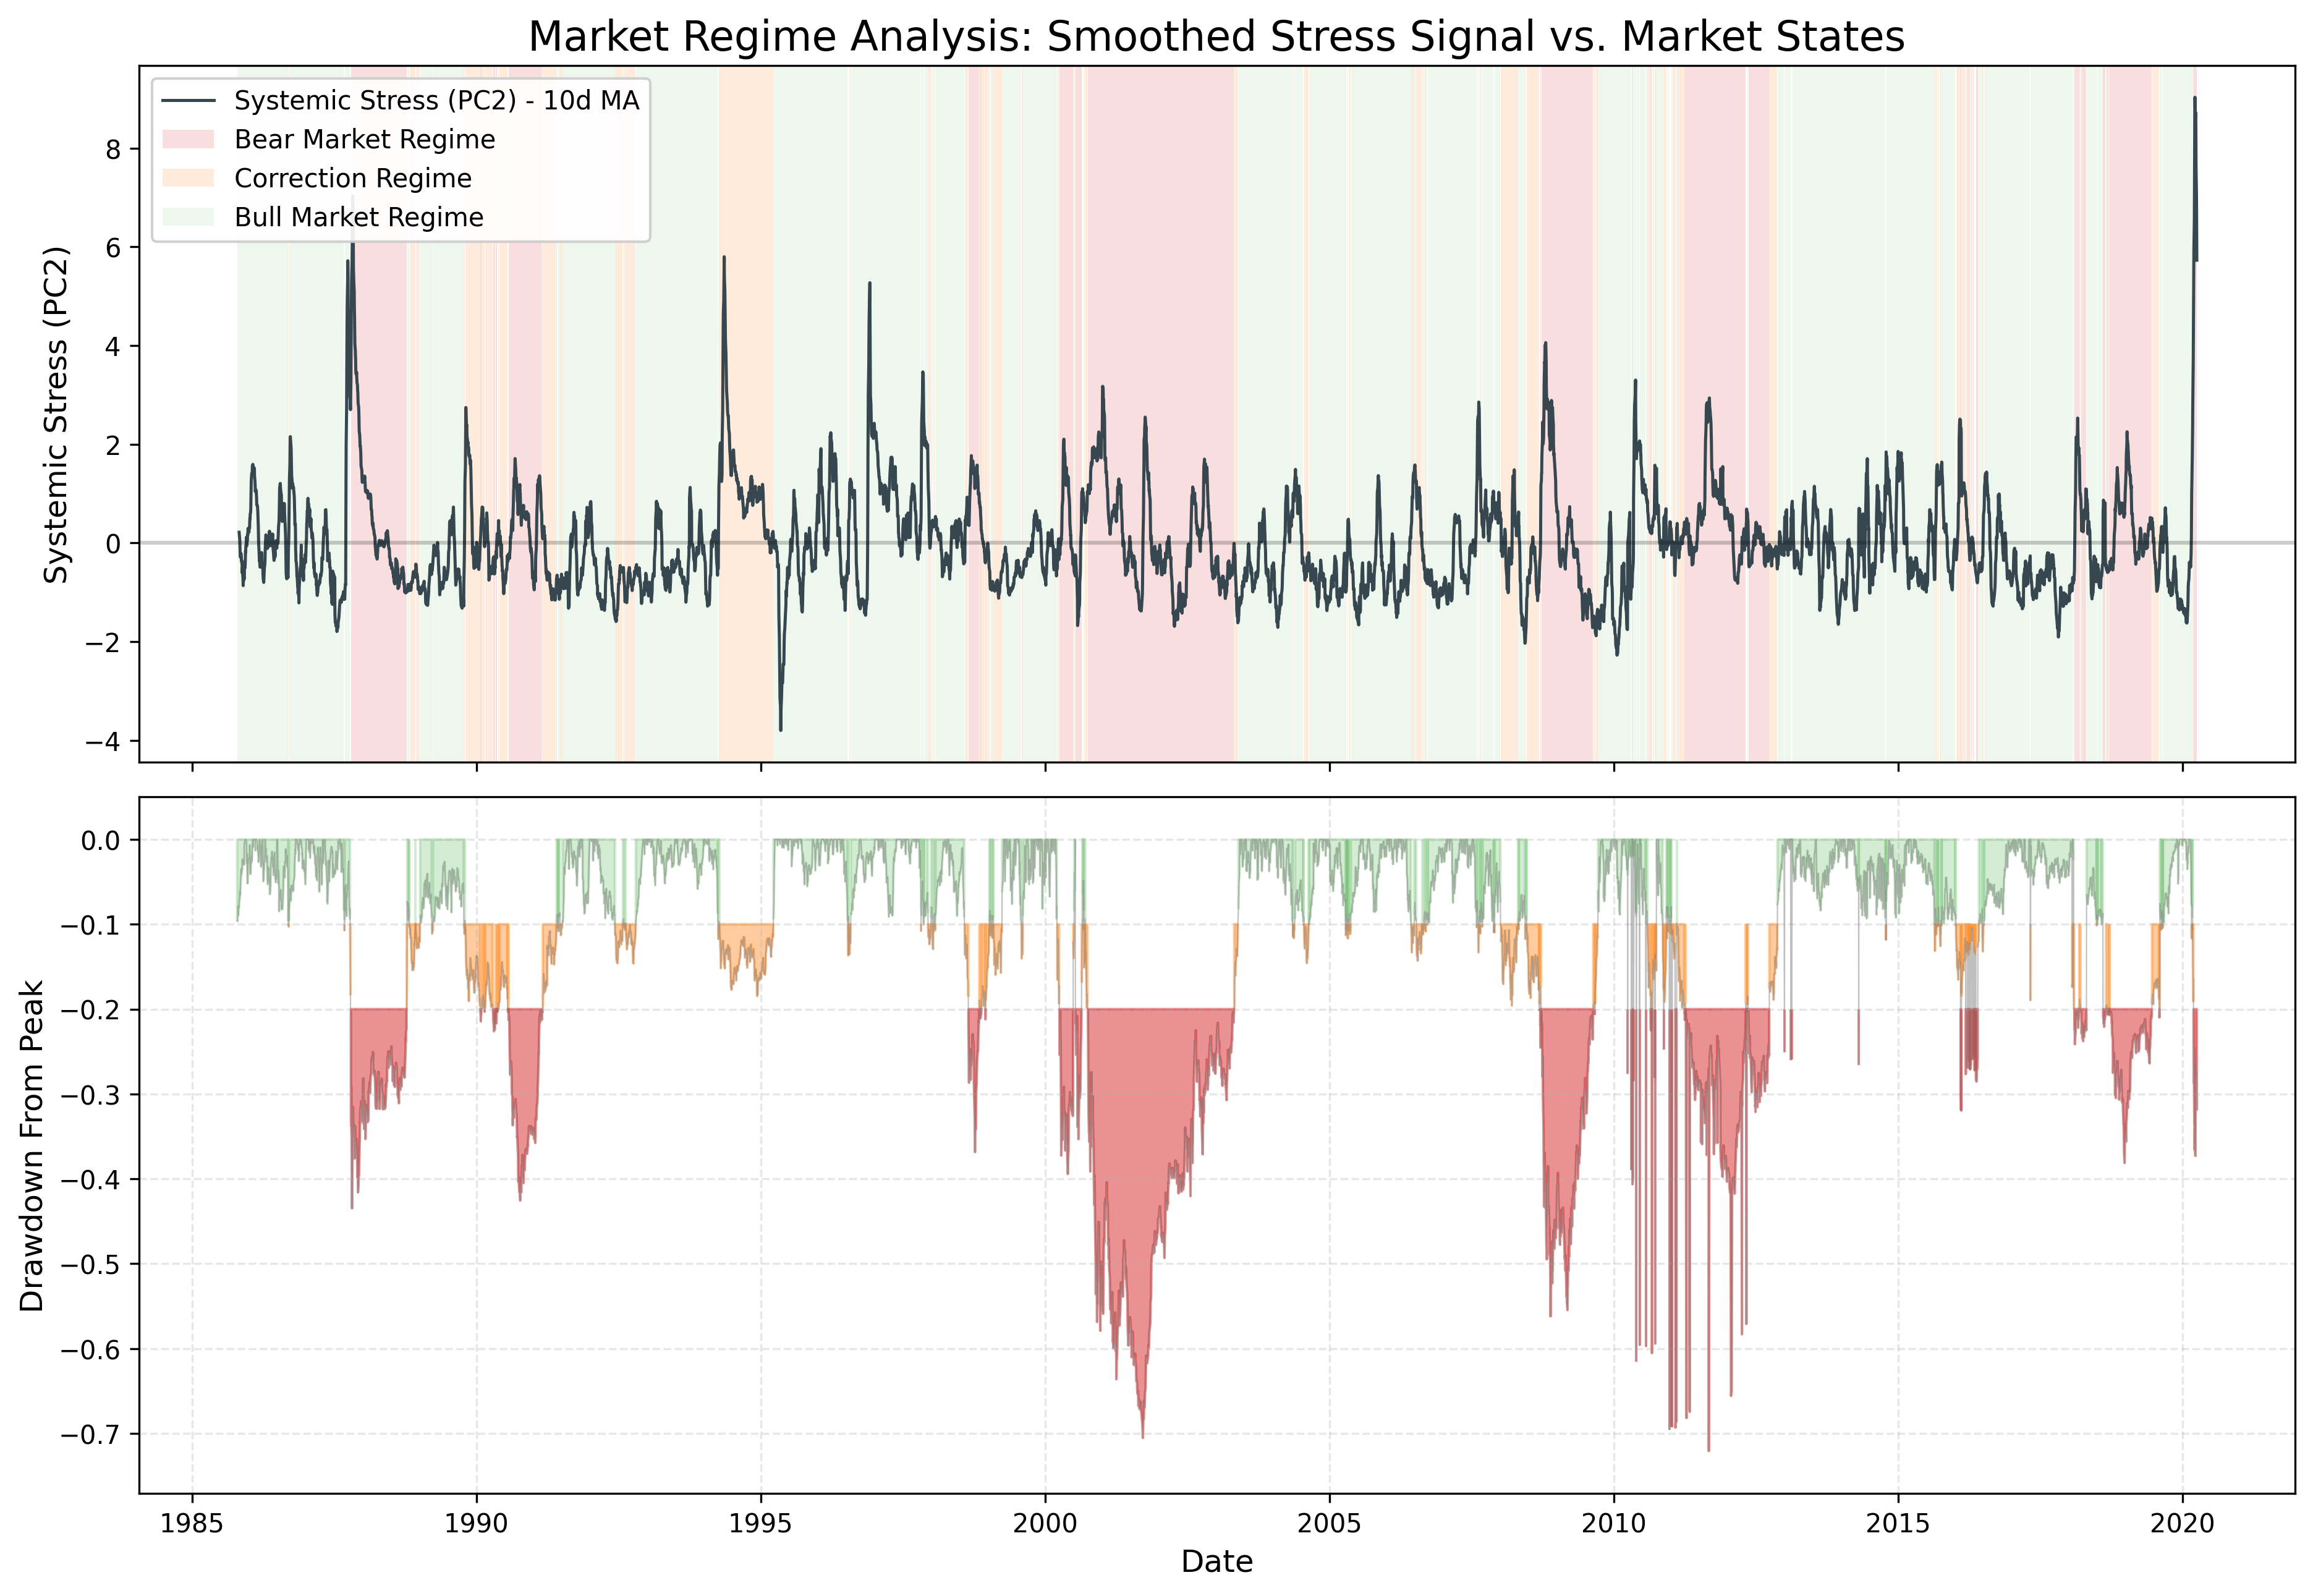

In [21]:
# Prepare Data
valid_start_date = moodindex['systemic_stress_pc2'].first_valid_index()
plot_data = moodindex.loc[valid_start_date:].copy()

# Setup Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [1, 1]}, dpi=300)
plt.subplots_adjust(hspace=0.05)

# Stress Index (10-Day MA) with Traffic Light Background

# Calculate and Plot the Smoothed Stress Line
# We apply .rolling(10).mean() to clean up the noise
stress_ma = plot_data['systemic_stress_pc2'].rolling(window=10).mean()

ax1.plot(plot_data.index, stress_ma, 
         color= '#37474f', linewidth=1.2, label='Systemic Stress (PC2) - 10d MA')

# Get Y-axis limits to fill the background completely
ymin, ymax = ax1.get_ylim()

# The Traffic Light Background (Discrete States)

# Bear Market Zone (Drawdown < -20%) -> RED Background
ax1.fill_between(plot_data.index, ymin, ymax, 
                 where=plot_data['market_drawdown'] < -0.20,
                 color='#d62728', alpha=0.15, linewidth=0, label='Bear Market Regime')

# Correction Zone (-10% to -20%) -> ORANGE Background
ax1.fill_between(plot_data.index, ymin, ymax, 
                 where=(plot_data['market_drawdown'] < -0.10) & (plot_data['market_drawdown'] >= -0.20),
                 color='#ff7f0e', alpha=0.15, linewidth=0, label='Correction Regime')

# Safe Zone (> -10%) -> GREEN Background
ax1.fill_between(plot_data.index, ymin, ymax, 
                 where=plot_data['market_drawdown'] >= -0.10,
                 color='#2ca02c', alpha=0.08, linewidth=0, label='Bull Market Regime')

# Formatting Top Plot
ax1.set_ylabel('Systemic Stress (PC2)', fontsize=12)
ax1.set_title('Market Regime Analysis: Smoothed Stress Signal vs. Market States', fontsize=16)
ax1.axhline(0, color='black', alpha=0.2, linestyle='-')
ax1.set_ylim(ymin, ymax) 
ax1.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)

# Drawdown Mirror 

ax2.plot(plot_data.index, plot_data['market_drawdown'], color='grey', linewidth=0.5, alpha=0.5)

ax2.fill_between(plot_data.index, plot_data['market_drawdown'], 0, 
                 where=plot_data['market_drawdown'] >= -0.10,
                 color='#2ca02c', alpha=0.2, label='Normal Volatility')

ax2.fill_between(plot_data.index, plot_data['market_drawdown'], -0.10, 
                 where=(plot_data['market_drawdown'] < -0.10) & (plot_data['market_drawdown'] >= -0.20),
                 color='#ff7f0e', alpha=0.4, label='Correction (-10%)')

ax2.fill_between(plot_data.index, plot_data['market_drawdown'], -0.20, 
                 where=plot_data['market_drawdown'] < -0.20,
                 color='#d62728', alpha=0.5, label='Bear Market (<-20%)')

ax2.set_ylabel('Drawdown From Peak', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(plot_data['market_drawdown'].min() - 0.05, 0.05)

# Date Formatting
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(5))

plt.show()

This plots confirms that 'systemic_stress_pc2' correctly aligns with major stress event.  

**Key insights**  
* Moving beyond the crisis versus not crisis from the previous plot, we use a continuous regime approach
    * **Bear market** (Red zone):
        * Observation: Our 'systemic_stress_pc2' indicator shows its highest, most violent spikes inside these zones (2000, 2008, 2020)
        * Conclusion: The indicator correctly inditifies major systemic capital destruction events as stress events
    * **Correction** (Organge zone):
        * Observation: The index shows moderate spikes (e.g., 1990, 1995, 2007)
        * Conclusion: These are not false positives. These periods represent significant market corrections where risk was high. The index correctly flagged "Fragility," even if a total collapse didn't follow. This proves the index acts as an early warning system.
    * **Bull market** (Green zone):
        * Observation: During sustained bull runs (e.g., 2004-2007, 2013-2015), the Stress Index remains low and flat.
     
**Nuances**  
* **False positive**: Overall, the indicator has a low rate of false alarms during healthy market conditions, as almost all spikes align with bearish market or correction event, while the index is mostly flat during the sustain bull runs (green zone). There is just a spike around 1997 that does not seem to align with any major event.
* **False negative**: Almost each red or orange zone is aligned with a peak of our indicator, meaning that the false negative rate is extremely low. The only "major" event that seems to be missed is the correction in 1993-1994. However, this can be explained by looking at what happened at this time. From the drawdown plot, we can seethat the Stock market went down, but it didn't crash violently. It was a slow decline. As such, the market accumulated a -10% loss (Orange Zone), but daily volatility never exploded. Our indicator thus correctly keeps the stress level low for this time window, as there is no systemic panic, just a repricing of index. We can see that for alsmost every other crisis the drawdown value clearly drops in a vertical line, whereas this case is just a slow increase.

### 12. Save results
The result are saved so they can be used for the follwing k-means algorithm.


In [22]:
features_df.rename(columns={'Date': 'date'}, inplace=True)
volatility_df.index.name = 'date'
features_extended.index.name = 'date'

# Save features DataFrame
output_path_features = Path('../data/processed/nasdaq_features.csv')
features_df.to_csv(output_path_features, index=False)
print(f"Features data saved to: {output_path_features}")
print(f"Shape: {features_df.shape}")

# Save volatility index
output_path_volatility = Path('../data/processed/market_volatility.csv')
volatility_df.to_csv(output_path_volatility, index=True)
print(f"\nVolatility index saved to: {output_path_volatility}")
print(f"Shape: {volatility_df.shape}")

# Save feature for K-means analysis
output_path_kmeans = Path('../data/processed/kmeans_features.csv')
print(f"\nFeatures for K-means saved to: {output_path_kmeans}")

# Save extended feature set for potential further analysis
output_path_extended = Path('../data/processed/extended_features.csv')
features_extended.to_csv(output_path_extended, index=True)
print(f"\nExtended features saved to: {output_path_extended}")
print(f"Shape: {features_extended.shape}")

# Save pca model for later use 
output_path_pca = '../data/processed'
joblib.dump(model_package, f'{output_path_pca}/pca_mood_model.joblib')
print(f"\nPCA Model saved to {output_path_pca}/pca_mood_model.joblib")

Features data saved to: ..\data\processed\nasdaq_features.csv
Shape: (12993961, 11)

Volatility index saved to: ..\data\processed\market_volatility.csv
Shape: (14662, 1)

Features for K-means saved to: ..\data\processed\kmeans_features.csv

Extended features saved to: ..\data\processed\extended_features.csv
Shape: (14663, 10)

PCA Model saved to ../data/processed/pca_mood_model.joblib
